# DSA 8301 — Statistical Inference for Big Data
## Kenya Housing Survey 2023/24 — Data Cleaning & Preparation

**Student:** [Your Name] | **Reg No:** [Your Reg No]
**Course:** DSA 8301 — Statistical Inference for Big Data
**Lecturer:** Prof. Jacob Ong'ala
**Institution:** Strathmore University
**Date:** June 2026

---

### Purpose of this notebook

This notebook is **Phase 2 (Preprocessing)** of the project workflow, plus a first pass at **Phase 3 (EDA)** —
just enough exploration to *choose* the variables and analytical story that the rest of the DSA8301
report (normality testing, parametric tests, nonparametric tests, regression) will run on.

It picks up exactly where `DSA8301_KHS_exploration.ipynb` left off: a master analytical frame of
**21,347 households × 443 columns**, built from the household spine plus 10 joined source files
(see `Data_Understanding.md` for full provenance).

**Why we go broad before narrow:** with 443 columns, jumping straight to "pick 4 variables" risks
choosing variables that look clean only because their problems haven't been surfaced yet. So the
order here is:

1. **Clean broadly** — using the missingness-tier framework and structural-missingness rules already
   documented in `Data_Understanding.md` (Section 6 and the per-pillar notes), so every cleaning
   decision is *informed*, not generic.
2. **Verify the unverified** — the four pre-computed columns (`prop_util`, `med_prop`, `med_brms`,
   `min_rent`) flagged as "provenance unverified" get checked here before they're used anywhere.
3. **Explore visually** — distributions, missingness patterns, and group splits across the cleaned
   frame, to see what's *actually* going on rather than what the codebook implies.
4. **Engineer** — build the small set of derived variables (`total_exp`, `rent_burden`,
   `persons_per_room`, quality composites, etc.) that the pillar logic says are "awesome to have".
5. **Decide** — end with 3–4 fully-specified candidate analytical stories, each with a stated
   variable list, types, and the test family (parametric vs nonparametric) it's *likely* to need —
   so Phase 3's normality testing in the next notebook has a short, deliberate list to check.

> **Note on continuity:** this notebook assumes the master frame was saved at the end of the
> exploration notebook. If you haven't done that yet, add this line as the last cell of
> `DSA8301_KHS_exploration.ipynb` (after Section 1.10) and re-run it once:
> ```python
> master.to_parquet(PQ / 'master_frame.parquet')
> ```


---
## 0. Setup & Continuity

Re-establish the environment and load the master frame produced in the exploration notebook.


In [143]:
# ── 0.1  Mount Google Drive (if not already mounted) ─────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [144]:
# ── 0.2  Core imports ─────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 120)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
sns.set_style('whitegrid')


In [145]:
# ── 0.3  Paths ────────────────────────────────────────────────────────────
DRIVE = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ    = DRIVE / 'data' / 'parquet'
RAW   = DRIVE / 'data' / 'raw'
FIGS  = DRIVE / 'outputs' / 'figures' / 'dsa8301'
TABS  = DRIVE / 'outputs' / 'tables'  / 'dsa8301'
for p in [FIGS, TABS]:
    p.mkdir(parents=True, exist_ok=True)

MASTER_PATH = PQ / 'master_frame.parquet'


In [146]:
# ── 0.4  Load the master frame ───────────────────────────────────────────
if MASTER_PATH.exists():
    master = pd.read_parquet(MASTER_PATH)
    print(f"Loaded master frame: {master.shape[0]:,} rows x {master.shape[1]} columns")
else:
    raise FileNotFoundError(
        "master_frame.parquet not found.\n"
        "Go back to the exploration notebook, after Section 1.10 (master frame build),\n"
        "and run: master.to_parquet(PQ / 'master_frame.parquet')"
    )


Loaded master frame: 21,347 rows x 443 columns


In [147]:
# ── 0.5  Variable Registry ──────────────────────────────────────────────
# A reference map of analysis-relevant variables across all loaded files.
# type: continuous | ordinal | binary | categorical

VARIABLE_REGISTRY = {

    # ── IDENTIFIERS & WEIGHTS ────────────────────────────────────────────
    'interview__key' : {'label': 'Household unique interview key',                   'type': 'id',          'file': 'household'},
    'a01'            : {'label': 'County code (1–47)',                               'type': 'categorical', 'file': 'household'},
    'countycode'     : {'label': 'County code string-padded (01–47)',                'type': 'categorical', 'file': 'household'},
    'a07_1'          : {'label': 'Urban/Rural stratum (1=Urban, 2=Rural)',           'type': 'binary',      'file': 'household'},
    'serial'         : {'label': 'KNBS household serial number',                     'type': 'id',          'file': 'household'},
    'hhweight'       : {'label': 'Household survey weight',                          'type': 'continuous',  'file': 'household'},

    # ── HOUSEHOLD — WATER & SANITATION ───────────────────────────────────
    'c01_1'          : {'label': 'Main drinking water source (1=piped HH, 4=borehole, 10=river)', 'type': 'ordinal',     'file': 'household'},
    'c01_2'          : {'label': 'Water collection method (1=piped, 5=fetched)',     'type': 'ordinal',     'file': 'household'},
    'c01_3'          : {'label': 'Water treated before drinking (0=No, 1=Yes)',      'type': 'binary',      'file': 'household'},
    'c01_4'          : {'label': 'Time to water source (minutes, one way)',          'type': 'continuous',  'file': 'household'},
    'c02_1'          : {'label': 'Secondary drinking water source',                  'type': 'ordinal',     'file': 'household'},
    'c04'            : {'label': 'Main toilet facility type (1=flush, 7=pit, 8=none)', 'type': 'ordinal',   'file': 'household'},
    'c05'            : {'label': 'Handwashing facility available (0=No, 1=Yes)',     'type': 'binary',      'file': 'household'},
    'c07'            : {'label': 'Handwashing materials present (4=soap+water)',     'type': 'ordinal',     'file': 'household'},
    'c14_1'          : {'label': 'Monthly water expenditure (KES)',                  'type': 'continuous',  'file': 'household'},

    # ── HOUSEHOLD — ENERGY ───────────────────────────────────────────────
    'c10'            : {'label': 'Main lighting source (1=grid electricity, 4=solar, 5=kerosene)', 'type': 'ordinal', 'file': 'household'},
    'c10_2'          : {'label': 'Hours of electricity supply per day',              'type': 'continuous',  'file': 'household'},
    'c10_4'          : {'label': 'Electricity connection type (0=prepaid, 1=postpaid)', 'type': 'binary',   'file': 'household'},
    'c11'            : {'label': 'Main cooking fuel (7=firewood, 9=charcoal, 11=LPG)', 'type': 'ordinal',  'file': 'household'},
    'c12'            : {'label': 'Primary cooking stove type (1=3-stone, 6=improved, 10=gas)', 'type': 'ordinal', 'file': 'household'},
    'c14_2'          : {'label': 'Monthly electricity expenditure (KES)',            'type': 'continuous',  'file': 'household'},
    'c14_3'          : {'label': 'Monthly other energy expenditure (KES)',           'type': 'continuous',  'file': 'household'},

    # ── HOUSEHOLD — ASSETS ───────────────────────────────────────────────
    'c13__1'         : {'label': 'Owns radio (0=No, 1=Yes)',                         'type': 'binary',      'file': 'household'},
    'c13__2'         : {'label': 'Owns mobile phone (0=No, 1=Yes)',                  'type': 'binary',      'file': 'household'},
    'c13__3'         : {'label': 'Owns television (0=No, 1=Yes)',                    'type': 'binary',      'file': 'household'},
    'c13__4'         : {'label': 'Owns computer/laptop (0=No, 1=Yes)',               'type': 'binary',      'file': 'household'},
    'c13__5'         : {'label': 'Owns motorcycle (0=No, 1=Yes)',                    'type': 'binary',      'file': 'household'},
    'c13__6'         : {'label': 'Owns motor vehicle (0=No, 1=Yes)',                 'type': 'binary',      'file': 'household'},
    'c13__7'         : {'label': 'Owns refrigerator (0=No, 1=Yes)',                  'type': 'binary',      'file': 'household'},
    'internet'       : {'label': 'Household has internet access (1=Yes)',            'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — INCOME & EXPENDITURE ─────────────────────────────────
    'g01a'           : {'label': 'Monthly food expenditure (KES)',                   'type': 'continuous',  'file': 'household'},
    'g01b'           : {'label': 'Monthly clothing expenditure (KES)',               'type': 'continuous',  'file': 'household'},
    'g01c'           : {'label': 'Monthly education expenditure (KES)',              'type': 'continuous',  'file': 'household'},
    'g01d'           : {'label': 'Monthly health expenditure (KES)',                 'type': 'continuous',  'file': 'household'},
    'g01e'           : {'label': 'Monthly transport expenditure (KES)',              'type': 'continuous',  'file': 'household'},
    'g01f'           : {'label': 'Monthly communication expenditure (KES)',          'type': 'continuous',  'file': 'household'},
    'g01g'           : {'label': 'Monthly recreation expenditure (KES)',             'type': 'continuous',  'file': 'household'},
    'g01h'           : {'label': 'Monthly housing cost expenditure (KES)',           'type': 'continuous',  'file': 'household'},
    'g01i'           : {'label': 'Monthly energy expenditure (KES)',                 'type': 'continuous',  'file': 'household'},
    'g01j'           : {'label': 'Monthly other expenditure (KES)',                  'type': 'continuous',  'file': 'household'},
    'g01k'           : {'label': 'Monthly remittances sent (KES)',                   'type': 'continuous',  'file': 'household'},
    'g02'            : {'label': 'Household pays rent (1=Yes, 2=No)',                'type': 'binary',      'file': 'household'},
    'g02_1'          : {'label': 'Monthly rent paid (KES)',                          'type': 'continuous',  'file': 'household'},
    'g03'            : {'label': 'Housing tenure type (1=owner, 2=tenant, 3=other)', 'type': 'categorical', 'file': 'household'},
    'g04'            : {'label': 'Owns other property (0=No, 1=Yes)',                'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — HOUSING PROBLEMS & ASPIRATIONS ───────────────────────
    'g05__1'         : {'label': 'Problem: overcrowding (0=No, 1=Yes)',              'type': 'binary',      'file': 'household'},
    'g05__2'         : {'label': 'Problem: poor water supply (0=No, 1=Yes)',         'type': 'binary',      'file': 'household'},
    'g05__3'         : {'label': 'Problem: poor sanitation (0=No, 1=Yes)',           'type': 'binary',      'file': 'household'},
    'g05__4'         : {'label': 'Problem: poor drainage (0=No, 1=Yes)',             'type': 'binary',      'file': 'household'},
    'g05__5'         : {'label': 'Problem: poor road access (0=No, 1=Yes)',          'type': 'binary',      'file': 'household'},
    'g05__6'         : {'label': 'Problem: insecurity (0=No, 1=Yes)',                'type': 'binary',      'file': 'household'},
    'g05__7'         : {'label': 'Problem: high rent/housing cost (0=No, 1=Yes)',    'type': 'binary',      'file': 'household'},
    'g05__8'         : {'label': 'Problem: poor structural condition (0=No, 1=Yes)', 'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — HOUSING PERCEPTION (h01–h11) ─────────────────────────
    'h01'            : {'label': 'Perceived structural quality (1=Good, 2=Fair, 3=Poor)',    'type': 'ordinal', 'file': 'household'},
    'h02'            : {'label': 'Perceived roof quality (1=Good, 2=Fair, 3=Poor)',          'type': 'ordinal', 'file': 'household'},
    'h03'            : {'label': 'Perceived wall quality (1=Good, 2=Fair, 3=Poor)',          'type': 'ordinal', 'file': 'household'},
    'h04'            : {'label': 'Perceived floor quality (1=Good, 2=Fair, 3=Poor)',         'type': 'ordinal', 'file': 'household'},
    'h05'            : {'label': 'Perceived ventilation adequacy (1=Good, 2=Fair, 3=Poor)',  'type': 'ordinal', 'file': 'household'},
    'h06'            : {'label': 'Perceived natural lighting (1=Good, 2=Fair, 3=Poor)',      'type': 'ordinal', 'file': 'household'},
    'h07'            : {'label': 'Perceived water supply adequacy (1=Good, 2=Fair, 3=Poor)', 'type': 'ordinal', 'file': 'household'},
    'h08'            : {'label': 'Perceived sanitation adequacy (1=Good, 2=Fair, 3=Poor)',   'type': 'ordinal', 'file': 'household'},
    'h09'            : {'label': 'Perceived waste disposal (1=Good, 2=Fair, 3=Poor)',        'type': 'ordinal', 'file': 'household'},
    'h10'            : {'label': 'Perceived neighbourhood security (1=Good, 2=Fair, 3=Poor)','type': 'ordinal', 'file': 'household'},
    'h11'            : {'label': 'Overall housing satisfaction (1=Good, 2=Fair, 3=Poor)',    'type': 'ordinal', 'file': 'household'},

    # ── HOUSEHOLD — TENURE & MOBILITY (j-module) ─────────────────────────
    'j04_1'          : {'label': 'Current tenure arrangement (1=owner, 0=other)',    'type': 'binary',      'file': 'household'},
    'j05'            : {'label': 'Has formal title/ownership document (0=No, 1=Yes)','type': 'binary',      'file': 'household'},
    'j09'            : {'label': 'Housing cost is a financial burden (0=No, 1=Yes)', 'type': 'binary',      'file': 'household'},
    'j10'            : {'label': 'Ever missed rent/mortgage payment (0=No, 1=Yes)',  'type': 'binary',      'file': 'household'},
    'j11'            : {'label': 'At risk of eviction in next 12 months (0=No, 1=Yes)', 'type': 'binary',   'file': 'household'},
    'j12_1'          : {'label': 'Years in current dwelling (1=<1yr, coded year otherwise)', 'type': 'ordinal', 'file': 'household'},
    'j13'            : {'label': 'Satisfied with current tenure (0=No, 1=Yes)',      'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — RENTAL MODULE (k-module, renters only ~32%) ──────────
    'k02'            : {'label': 'Written tenancy agreement exists (1=Yes, 2=No)',   'type': 'binary',      'file': 'household'},
    'k05'            : {'label': 'Monthly rent (KES)',                               'type': 'continuous',  'file': 'household'},
    'k09'            : {'label': 'Lease type (1=monthly, 2=annual)',                 'type': 'categorical', 'file': 'household'},
    'k21'            : {'label': 'Rent arrears status (1=in arrears, others)',       'type': 'ordinal',     'file': 'household'},
    'min_rent'       : {'label': 'Minimum rent in PSU — local market floor (KES)',   'type': 'continuous',  'file': 'household'},

    # ── HOUSEHOLD — OWNED DWELLING MODULE (l-module) ─────────────────────
    'l07'            : {'label': 'Year dwelling was built',                          'type': 'continuous',  'file': 'household'},
    'l13'            : {'label': 'Monthly mortgage/housing loan repayment (KES)',    'type': 'continuous',  'file': 'household'},
    'l14'            : {'label': 'Estimated market value of dwelling (KES)',         'type': 'continuous',  'file': 'household'},
    'l15'            : {'label': 'Imputed monthly housing cost/rent equivalent (KES)', 'type': 'continuous','file': 'household'},
    'l19'            : {'label': 'Plot/land size (decimal: 12=1 acre)',              'type': 'continuous',  'file': 'household'},
    'l21'            : {'label': 'Major renovation done (0=No, 1=Yes)',              'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — ENVIRONMENT & HAZARDS (e-module) ─────────────────────
    'e01'            : {'label': 'Solid waste disposal method (0=collected, 9=open dump)', 'type': 'ordinal', 'file': 'household'},
    'e05'            : {'label': 'Proximity to waste dump/quarry (0=No, 1=Yes)',     'type': 'binary',      'file': 'household'},
    'e06'            : {'label': 'Flood exposure (0=none, 1=severe, 2=mild)',        'type': 'ordinal',     'file': 'household'},
    'e07'            : {'label': 'Mudslide/erosion exposure (0=none, 1=severe, 2=mild)', 'type': 'ordinal', 'file': 'household'},
    'e08'            : {'label': 'Terrain/slope type (1=flat, 2=gentle, 3=hilly, 4=steep)', 'type': 'ordinal', 'file': 'household'},

    # ── HOUSEHOLD — LAND OWNERSHIP (i00) ─────────────────────────────────
    'i00'            : {'label': 'Household owns land (0=No, 1=Yes)',                'type': 'binary',      'file': 'household'},

    # ── HOUSEHOLD — DERIVED / COMPUTED ───────────────────────────────────
    'prop_util'      : {'label': 'Utilities as proportion of income (ratio)',        'type': 'continuous',  'file': 'household'},
    'med_prop'       : {'label': 'Median utility-to-income ratio, county level',     'type': 'continuous',  'file': 'household'},
    'utilities'      : {'label': 'Household pays for utilities (0=No, 1=Yes)',       'type': 'binary',      'file': 'household'},
    'ctymin_ut'      : {'label': 'County-level minimum utility cost (KES)',          'type': 'continuous',  'file': 'household'},
    'med_brms'       : {'label': 'Median bedrooms in county (rooms)',                'type': 'continuous',  'file': 'household'},
    'sf'             : {'label': 'Slum/informal settlement flag (1=slum, 2=non-slum)', 'type': 'binary',    'file': 'household'},
    'pln'            : {'label': 'Planning status of settlement (coded)',            'type': 'categorical', 'file': 'household'},

    # ── DWELLING FILE ─────────────────────────────────────────────────────
    'd01'            : {'label': 'Dwelling tenure type (1=owner-occupied, 2=rented, 3=other)', 'type': 'categorical', 'file': 'dwelling'},
    'd03'            : {'label': 'Dwelling type (1=conventional house, 4=flat, 7=traditional)', 'type': 'categorical', 'file': 'dwelling'},
    'd05'            : {'label': 'Located in approved building (1=Yes, 0=No)',       'type': 'binary',      'file': 'dwelling'},
    'd06'            : {'label': 'Building has planning approval (1=Yes, 0=No)',     'type': 'binary',      'file': 'dwelling'},
    'd07'            : {'label': 'Dwelling in hazard-prone area (1=Yes, 0=No)',      'type': 'binary',      'file': 'dwelling'},
    'd08'            : {'label': 'Outer wall material (1=stone/brick, 3=timber, 5=mud/earth)', 'type': 'ordinal', 'file': 'dwelling'},
    'd09'            : {'label': 'Roof material (1=iron sheets, 2=tiles, 3=grass/thatch)', 'type': 'ordinal', 'file': 'dwelling'},
    'd10'            : {'label': 'Floor material (1=cement, 2=tiles, 3=earth)',      'type': 'ordinal',     'file': 'dwelling'},
    'd11'            : {'label': 'Number of rooms in dwelling',                      'type': 'continuous',  'file': 'dwelling'},
    'd11_1'          : {'label': 'Floor area of dwelling (sq m)',                    'type': 'continuous',  'file': 'dwelling'},
    'd11_2'          : {'label': 'Number of bedrooms',                              'type': 'continuous',  'file': 'dwelling'},
    'd12'            : {'label': 'Number of rooms used for sleeping',                'type': 'continuous',  'file': 'dwelling'},

    # ── INDIVIDUAL FILE ───────────────────────────────────────────────────
    'b04'            : {'label': 'Sex of individual (1=Male, 2=Female)',             'type': 'binary',      'file': 'individual'},
    'b05_years'      : {'label': 'Age in completed years',                           'type': 'continuous',  'file': 'individual'},
    'b07'            : {'label': 'Marital status (1=never married, 2=married, 3=divorced, 4=widowed)', 'type': 'categorical', 'file': 'individual'},
    'b10'            : {'label': 'Currently attending school (0=No, 1=Yes)',         'type': 'binary',      'file': 'individual'},
    'b11'            : {'label': 'Literacy status (0=illiterate, 1=literate)',       'type': 'binary',      'file': 'individual'},
    'ken_edu_isced11': {'label': 'Highest education level (ISCED-11: 3=primary, 6=secondary, 16=tertiary)', 'type': 'ordinal', 'file': 'individual'},
    'any_disability' : {'label': 'Any functional disability (0=No, 1=Yes)',          'type': 'binary',      'file': 'individual'},
    'resid'          : {'label': 'Residence type (1=Urban, 2=Rural)',                'type': 'binary',      'file': 'individual'},
    'hhsize'         : {'label': 'Total persons in household',                       'type': 'continuous',  'file': 'individual'},
    'age_dep'        : {'label': 'Age dependency status (0=child <15, 15=working age, 65=elderly)', 'type': 'ordinal', 'file': 'individual'},
    'wap'            : {'label': 'Working-age population flag (1=WAP, NaN=not)',     'type': 'binary',      'file': 'individual'},
    'inw'            : {'label': 'Individual survey weight',                         'type': 'continuous',  'file': 'individual'},

    # ── LAND PARCELS FILE ─────────────────────────────────────────────────
    'i01_3'          : {'label': 'Land ownership type (1=freehold, 2=leasehold, 3=customary)', 'type': 'categorical', 'file': 'land_parcels'},
    'i05'            : {'label': 'Land has title deed (1=Yes, 3=no, 14=other)',      'type': 'ordinal',     'file': 'land_parcels'},
    'i06'            : {'label': 'Land use type (1=residential, 12=agricultural, 14=mixed)', 'type': 'categorical', 'file': 'land_parcels'},
    'i08'            : {'label': 'Land dispute in last 5 years (0=No, 1=Yes)',       'type': 'binary',      'file': 'land_parcels'},
    'i10'            : {'label': 'Land registered (0=No, 1=Yes)',                   'type': 'binary',      'file': 'land_parcels'},
    'i12'            : {'label': 'Land used as loan collateral (0=No, 1=Yes)',       'type': 'binary',      'file': 'land_parcels'},

}

# ── Summary ──────────────────────────────────────────────────────────────
_reg_df = pd.DataFrame(VARIABLE_REGISTRY).T
print(f'  Total variables registered: {len(VARIABLE_REGISTRY)}')
print()
print(_reg_df.groupby(['file', 'type']).size().rename('count').to_string())

  Total variables registered: 125

file          type       
dwelling      binary          3
              categorical     2
              continuous      4
              ordinal         3
household     binary         34
              categorical     5
              continuous     29
              id              2
              ordinal        25
individual    binary          6
              categorical     1
              continuous      3
              ordinal         2
land_parcels  binary          3
              categorical     2
              ordinal         1


In [148]:
# ── 0.6  Re-load the variable registry (needed to know var types) ────────
# Paste / import the same VARIABLE_REGISTRY dict built in Section 1.3 of the
# exploration notebook. Re-declared here so this notebook is runnable standalone.
# (For brevity, only loaded — full dict is identical to the exploration notebook.)

# %run is the simplest path if both notebooks are in the same Drive folder:
# %run '/content/drive/MyDrive/KHS_Dissertation/notebooks/DSA8301_KHS_exploration.ipynb'
# Otherwise, paste the VARIABLE_REGISTRY dict from Section 1.3 here.

assert 'VARIABLE_REGISTRY' in dir(), \
    "VARIABLE_REGISTRY not found — import it from the exploration notebook (Section 1.3)."

reg_df = pd.DataFrame(VARIABLE_REGISTRY).T
reg_df.index.name = 'variable'
print(f"Registry covers {len(reg_df)} of {master.shape[1]} master columns "
      f"({len(reg_df)/master.shape[1]:.0%}).")


Registry covers 125 of 443 master columns (28%).


---
## 1. Initial Audit

Before applying *any* informed cleaning rule, get a plain inventory: shape, types, duplicates, and
a full missingness scan. This is the "before" picture we'll compare the "after" picture against in
Section 10.


In [149]:
# ── 1.1  Shape, dtypes, duplicates ───────────────────────────────────────
print(f"Shape: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Duplicate rows (full):            {master.duplicated().sum()}")
print(f"Duplicate interview__key values:  {master['interview__key'].duplicated().sum()}")
print()
print("Dtype breakdown:")
print(master.dtypes.value_counts())


Shape: 21,347 rows x 443 columns
Duplicate rows (full):            0
Duplicate interview__key values:  0

Dtype breakdown:
float64    363
object      40
int8        22
float32     15
Int64        1
int32        1
int16        1
Name: count, dtype: int64


In [150]:
# ── 1.2  Full missingness scan (BEFORE cleaning) ─────────────────────────
missing_before = pd.DataFrame({
    'n_missing': master.isnull().sum(),
    'pct_missing': (master.isnull().mean() * 100).round(2)
}).sort_values('pct_missing', ascending=False)

print(f"Columns with 0% missing:        {(missing_before['pct_missing'] == 0).sum()}")
print(f"Columns with >0% missing:       {(missing_before['pct_missing'] > 0).sum()}")
print(f"Columns with >60% missing:      {(missing_before['pct_missing'] > 60).sum()}")
print()
missing_before.head(20)


Columns with 0% missing:        86
Columns with >0% missing:       357
Columns with >60% missing:      166



,n_missing,pct_missing
k10,21333,99.9300
k32,21285,99.7100
k27,21212,99.3700
k24_1,21212,99.3700
l24,21198,99.3000
l27__96,21179,99.2100
l27__1,21179,99.2100
l27__6,21179,99.2100
l27__4,21179,99.2100
l27__5,21179,99.2100


In [151]:
# ── Normalise hhsize column name ─────────────────────────────────────────
if 'hhsize' in master.columns and 'hh_size' not in master.columns:
    master = master.rename(columns={'hhsize': 'hh_size'})
    print("Renamed 'hhsize' -> 'hh_size' for consistency.")
elif 'hh_size' in master.columns:
    print("'hh_size' already present.")
else:
    print("WARNING: no household size column found (expected 'hh_size' or 'hhsize').")

'hh_size' already present.


In [152]:
# # ── 1.4  Enforce column dtypes on master ─────────────────────────────────
# # Run this AFTER all cleaning is complete (i.e., after Section 8),
# # not here — this cell is a reference. Repeat at end of Section 12.

# # Categorical columns (county code, planning status, dwelling type, etc.)
# CATEGORICAL_COLS = [c for c in ['a01', 'countycode', 'pln', 'd01', 'd03', 'g03', 'k09',
#                                   'i01_3', 'i06', 'b07']
#                     if c in master.columns]

# # Binary columns (0/1 encoded — keep as Int64 to support NA-awareness)
# BINARY_COLS = [c for c in reg_df[reg_df['type'] == 'binary'].index
#                if c in master.columns]

# # Ordinal columns (keep numeric but add a note; do NOT cast to string)
# ORDINAL_COLS = [c for c in reg_df[reg_df['type'] == 'ordinal'].index
#                 if c in master.columns]

# for col in CATEGORICAL_COLS:
#     master[col] = master[col].astype('category')

# for col in BINARY_COLS:
#     master[col] = master[col].astype('Int64')  # nullable int, supports NA

# print("Dtype enforcement applied:")
# print(f"  Categorical : {len(CATEGORICAL_COLS)} cols")
# print(f"  Binary      : {len(BINARY_COLS)} cols")
# print(f"  Ordinal     : {len(ORDINAL_COLS)} cols (kept numeric)")

---
## 2. Sentinel & Invalid Value Scan

**Why this comes before missingness tiering:** survey instruments encode "Don't know", "Refused",
and "Not applicable" as numeric sentinel codes (commonly `8`, `9`, `98`, `99`, `998`, `999`, `-99`).
If left as-is, these are read as *valid* numeric values — they inflate means, distort outlier
detection, and make a column look "complete" when it is actually full of non-responses.

This step must happen **before** the missingness-tier classification in Section 3, otherwise the
tiers themselves are wrong.

### 2.1 Plausibility scan — continuous variables


In [153]:
# ── 2.1  Plausibility checks on key continuous variables ────────────────
# Flag implausible values that are very likely sentinel codes or entry errors,
# not "valid extreme" observations.

plausibility_checks = {
    'b05_years'      : (0, 110),     # age in years
    'l07'            : (1900, 2026), # year dwelling built
    'c01_4'          : (0, 600),     # minutes to water source (10 hrs cap)
    'c10_2'          : (0, 24),      # hours of electricity per day
    'g01a': (0, None), 'g01b': (0, None), 'g01c': (0, None), 'g01d': (0, None),
    'g01e': (0, None), 'g01f': (0, None), 'g01g': (0, None), 'g01h': (0, None),
    'g01i': (0, None), 'g01j': (0, None), 'g01k': (0, None),
    'k05' : (0, None),  # rent must be >= 0
    'l13' : (0, None),  # mortgage repayment >= 0
    'l14' : (0, None),  # market value >= 0
}

plausibility_report = []
for col, (low, high) in plausibility_checks.items():
    if col not in master.columns:
        continue
    s = master[col]
    n_low  = (s < low).sum()  if low  is not None else 0
    n_high = (s > high).sum() if high is not None else 0
    if n_low or n_high:
        plausibility_report.append({
            'variable': col, 'rule': f'[{low}, {high}]',
            'n_below': n_low, 'n_above': n_high,
            'min_observed': s.min(), 'max_observed': s.max()
        })

plaus_df = pd.DataFrame(plausibility_report)
plaus_df


,variable,rule,n_below,n_above,min_observed,max_observed
0,l07,"[1900, 2026]",1,0,0.0000,2024.0000
1,c01_4,"[0, 600]",0,1,1.0000,1000.0000
2,c10_2,"[0, 24]",4640,1720,-1.0000,168.0000


### 2.2 Sentinel-code scan — ordinal / categorical variables

For ordinal and categorical variables whose registry entry implies a small set of valid codes
(e.g., `e06` flood exposure should be `{0, 1, 2}`), scan the actual `value_counts()` for outlier
codes like `8`, `9`, `98`, `99` that signal "not stated" rather than a real category.


In [154]:
# ── 2.2  Sentinel-code scan on ordinal/categorical registry variables ────
SENTINEL_CODES = {8, 9, 98, 99, 998, 999, -99, -98}

sentinel_report = []
ordinal_cat_vars = reg_df[reg_df['type'].isin(['ordinal', 'categorical', 'binary'])].index

for col in ordinal_cat_vars:
    if col not in master.columns:
        continue
    vc = master[col].value_counts(dropna=True)
    found = SENTINEL_CODES.intersection(set(vc.index))
    for code_val in found:
        sentinel_report.append({
            'variable': col,
            'sentinel_code': code_val,
            'n_rows': vc[code_val],
            'pct_of_nonnull': round(vc[code_val] / vc.sum() * 100, 2)
        })

sentinel_df = pd.DataFrame(sentinel_report).sort_values('n_rows', ascending=False) \
    if sentinel_report else pd.DataFrame(columns=['variable','sentinel_code','n_rows','pct_of_nonnull'])
sentinel_df


,variable,sentinel_code,n_rows,pct_of_nonnull
15,c11,9.0000,11503,53.8900
9,c04,8.0000,4229,19.8100
3,c01_1,9.0000,1951,9.1400
23,pln,8.0000,1951,54.5000
5,c01_2,9.0000,1692,7.9300
7,c02_1,9.0000,1504,7.0500
4,c01_2,8.0000,1224,5.7300
16,c12,8.0000,984,4.6500
0,a01,8.0000,637,2.9800
2,c01_1,8.0000,632,2.9600


In [155]:
# ── 2.3  Apply corrections ────────────────────────────────────────────────
# Decision log — fill in after inspecting plaus_df / sentinel_df above.
# Pattern: replace sentinel codes with NaN (they become "missing" and flow into
# the tier-based treatment in Sections 5-6), and clip/flag implausible continuous values.

CORRECTIONS_LOG = []  # (variable, action, n_affected)

# Example pattern — repeat per finding from 2.1 / 2.2:
# master.loc[master['c10_2'] > 24, 'c10_2'] = np.nan
# CORRECTIONS_LOG.append(('c10_2', 'set >24 to NaN (implausible hours/day)', n_affected))

# for col, code_val in sentinel_df[['variable','sentinel_code']].itertuples(index=False):
#     n_affected = (master[col] == code_val).sum()
#     master.loc[master[col] == code_val, col] = np.nan
#     CORRECTIONS_LOG.append((col, f'sentinel code {code_val} -> NaN', n_affected))

print(f"Corrections logged so far: {len(CORRECTIONS_LOG)}")
pd.DataFrame(CORRECTIONS_LOG, columns=['variable', 'action', 'n_affected'])


Corrections logged so far: 0


,variable,action,n_affected


---
## 3. Missingness Tier Classification

Re-run the missingness scan **after** sentinel correction, and classify every column into the four
tiers defined in `Data_Understanding.md` Section 6:

| Tier | Missing % | Default treatment |
|---|---|---|
| Complete | 0% | Use as-is |
| Low | 1–20% | Group-median imputation, stratified by tenure type |
| Moderate | 21–60% | Use with imputation where interpretable; flag as imputed |
| High | >60% | Exclude from formula construction; retain as contextual where theoretically motivated |

**Important:** this tier table is the *default*. Section 4 overrides it for the columns we know
have *structural* (meaningful) missingness — those must never be median-imputed.


In [156]:
# ── 3.1  Re-scan missingness post-correction & assign tiers ──────────────
missing_after_sentinel = (master.isnull().mean() * 100).round(2)

def tier(pct):
    if pct == 0:
        return 'Complete'
    elif pct <= 20:
        return 'Low'
    elif pct <= 60:
        return 'Moderate'
    else:
        return 'High'

tier_df = pd.DataFrame({'pct_missing': missing_after_sentinel})
tier_df['tier'] = tier_df['pct_missing'].apply(tier)
tier_df = tier_df.join(reg_df[['type', 'file', 'label']], how='left')

print("Tier counts:")
print(tier_df['tier'].value_counts())
print()
print("High-missingness columns (>60%):")
tier_df[tier_df['tier'] == 'High'].sort_values('pct_missing', ascending=False)


Tier counts:
tier
High        166
Low         122
Complete     86
Moderate     69
Name: count, dtype: int64

High-missingness columns (>60%):


,pct_missing,tier,type,file,label
k10,99.9300,High,NaN,NaN,NaN
k32,99.7100,High,NaN,NaN,NaN
k27,99.3700,High,NaN,NaN,NaN
k24_1,99.3700,High,NaN,NaN,NaN
l24,99.3000,High,NaN,NaN,NaN
...,...,...,...,...,...
c10_3,65.4800,High,NaN,NaN,NaN
fin_avg_tenure_months,64.0400,High,NaN,NaN,NaN
mort_ltv_ratio,63.6000,High,NaN,NaN,NaN
c06,62.9500,High,NaN,NaN,NaN


In [157]:
# ── 3.2  Moderate-tier columns — these get imputed-with-flag in Section 6 ─
tier_df[tier_df['tier'] == 'Moderate'].sort_values('pct_missing', ascending=False)


,pct_missing,tier,type,file,label
mort_avg_term_years,59.8700,Moderate,NaN,NaN,NaN
c09__2,56.7300,Moderate,NaN,NaN,NaN
c09__3,56.7300,Moderate,NaN,NaN,NaN
c09__1,56.7300,Moderate,NaN,NaN,NaN
c09__5,56.7300,Moderate,NaN,NaN,NaN
c09__96,56.7300,Moderate,NaN,NaN,NaN
c09__6,56.7300,Moderate,NaN,NaN,NaN
c09__7,56.7300,Moderate,NaN,NaN,NaN
c09__4,56.7300,Moderate,NaN,NaN,NaN
lp_any_collateral,55.7500,Moderate,NaN,NaN,NaN


---
## 4. Structural Missingness — Verification & Encoding

`Data_Understanding.md` documents three families of "missing-but-meaningful" variables. Before
trusting that documentation, **verify each claim against the actual data** — this is the
"experiment all suggested possible angles" step for missingness.

1. `lp_*` columns (~55% missing) ↔ should align with `i00 == 0` (no land)
2. `k05` (rent, ~67.5% missing) ↔ should align with `g02 != 1` (not a renter)
3. `mort_*` / `fin_*` county aggregates (60–81% missing) ↔ should align with counties that have no
   formal mortgage/finance institutions in the source files (Nairobi-dominated)

If verified, these columns are **encoded**, not imputed: a null becomes a meaningful zero/flag
rather than a "fill in the average".


In [158]:
# ── 4.1  Verify: lp_* missingness <-> i00 == 0 (no land) ─────────────────
lp_cols = [c for c in master.columns if c.startswith('lp_')]
print(f"lp_* columns found: {lp_cols}")

if lp_cols and 'i00' in master.columns:
    lp_missing_mask = master[lp_cols[0]].isnull()
    crosstab_lp = pd.crosstab(master['i00'], lp_missing_mask,
                               rownames=['i00 (owns land)'],
                               colnames=[f'{lp_cols[0]} is null'])
    print(crosstab_lp)
    agreement = (master['i00'].eq(0) == lp_missing_mask).mean()
    print(f"\nAgreement rate (i00==0  <->  {lp_cols[0]} is null): {agreement:.2%}")


lp_* columns found: ['lp_n_parcels', 'lp_primary_tenure', 'lp_has_title', 'lp_primary_use', 'lp_any_dispute', 'lp_any_registered', 'lp_any_collateral']
lp_n_parcels is null  False  True 
i00 (owns land)                   
0.0000                    0  11639
1.0000                 9707      0

Agreement rate (i00==0  <->  lp_n_parcels is null): 100.00%


In [159]:
# ── 4.2  Encode structural missingness in lp_* columns ────────────────────
# lp_n_parcels is numeric → fill with 0
# all others are categorical → fill with 'No land'

lp_numeric = ['lp_n_parcels']
lp_categorical = [c for c in lp_cols if c not in lp_numeric]

for col in lp_numeric:
    if col in master.columns:
        master[col] = master[col].fillna(0)

for col in lp_categorical:
    if col in master.columns:
        master[col] = master[col].fillna('No land').astype(str)

print("lp_* columns after encoding:")
for col in lp_cols:
    if col in master.columns:
        print(f"  {col}: dtype={master[col].dtype}, sample values={master[col].unique()[:4].tolist()}")

lp_* columns after encoding:
  lp_n_parcels: dtype=float64, sample values=[5.0, 1.0, 0.0, 2.0]
  lp_primary_tenure: dtype=object, sample values=['1.0', 'No land', '2.0', '3.0']
  lp_has_title: dtype=object, sample values=['1.0', 'No land', '0.0']
  lp_primary_use: dtype=object, sample values=['1.0', 'No land', '14.0', '10.0']
  lp_any_dispute: dtype=object, sample values=['1.0', 'No land', '0.0', '98.0']
  lp_any_registered: dtype=object, sample values=['1.0', 'No land', '0.0', '98.0']
  lp_any_collateral: dtype=object, sample values=['5.0', '1.0', 'No land', '3.0']


In [160]:
# ── 4.3  Verify: mort_*/fin_* missingness <-> county has no institutions ─
mort_fin_cols = [c for c in master.columns if c.startswith(('mort_', 'fin_', 'loan_'))]
print(f"County-finance columns: {mort_fin_cols}")

county_missing = (
    master.groupby('a01')[mort_fin_cols]
    .apply(lambda g: g.isnull().mean())
    .mean(axis=1)
    .sort_values(ascending=False)
)
print("\nCounties with HIGHEST average missingness across mort_/fin_/loan_ columns:")
print(county_missing.head(10))
print("\nCounties with LOWEST average missingness (i.e. have institutions, e.g. Nairobi=47):")
print(county_missing.tail(10))


County-finance columns: ['mort_interest_rate', 'mort_ltv_ratio', 'mort_avg_term_years', 'mort_n_providers', 'loan_avg_size', 'loan_outstanding', 'loan_n_providers', 'fin_portfolio', 'fin_avg_tenure_months', 'fin_n_financiers']

Counties with HIGHEST average missingness across mort_/fin_/loan_ columns:
a01
4    1.0000
7    1.0000
8    1.0000
9    1.0000
11   1.0000
23   1.0000
17   1.0000
38   1.0000
44   1.0000
29   0.4000
dtype: float64

Counties with LOWEST average missingness (i.e. have institutions, e.g. Nairobi=47):
a01
1    0.1000
36   0.1000
14   0.0000
12   0.0000
19   0.0000
22   0.0000
31   0.0000
18   0.0000
32   0.0000
47   0.0000
dtype: float64


In [161]:
# ── 4.4  Encode structural missingness ───────────────────────────────────
# lp_* : null -> 0 / "no land" category, PLUS keep i00 as the master land-ownership flag.
for col in lp_cols:
    if master[col].dtype == bool or set(master[col].dropna().unique()) <= {0, 1, 0.0, 1.0}:
        master[col] = master[col].fillna(0)               # binary: no land -> 0 contribution
    else:
        master[col] = master[col].fillna('No land')        # categorical: explicit "not applicable"

# k05 : null (non-renters) is structurally correct. Create an explicit renter flag,
# and leave k05 as NaN — rent_burden (Section 9) will be computed only for renters.
master['is_renter'] = (master['g02'] == 1).astype(int)

# mort_/fin_/loan_ county aggregates: null -> county has no formal market/institution.
# Encode as a binary exclusion flag PLUS fill the continuous value with 0
# (0 = "no formal mortgage/finance market", which is the substantive interpretation).
for col in mort_fin_cols:
    flag_col = f'{col}_market_absent'
    master[flag_col] = master[col].isnull().astype(int)
    master[col] = master[col].fillna(0)

print("Structural missingness encoded:")
print(f"  lp_* columns (n={len(lp_cols)}): filled with 0 / 'No land'")
print(f"  is_renter flag created from g02")
print(f"  k05 left as NaN for non-renters (structural, not imputed)")
print(f"  mort_/fin_/loan_ columns (n={len(mort_fin_cols)}): "
      f"_market_absent flags created, values filled with 0")


Structural missingness encoded:
  lp_* columns (n=7): filled with 0 / 'No land'
  is_renter flag created from g02
  k05 left as NaN for non-renters (structural, not imputed)
  mort_/fin_/loan_ columns (n=10): _market_absent flags created, values filled with 0


---
## 5. Provenance Verification — Pre-Computed Columns

`Data_Understanding.md` Section 3.5 flags four columns as **"provenance unverified — do not use
before confirmation"**: `prop_util`, `med_prop`, `med_brms`, `min_rent`. Each has a working
hypothesis about its construction. We test each hypothesis here; columns that fail verification are
**excluded** from feature engineering in Section 9, not silently used.


In [162]:
# ── 5.1  Verify prop_util: hypothesis = utilities / (total_exp or k05) ───
# Utilities = water + electricity + other energy expenditure
utility_cols = [c for c in ['c14_1', 'c14_2', 'c14_3'] if c in master.columns]
master['_utilities_exp'] = master[utility_cols].sum(axis=1, skipna=True)

# Candidate denominators
master['_total_exp_candidate'] = master[[c for c in
    ['g01a','g01b','g01c','g01d','g01e','g01f','g01g','g01h','g01i','g01j','g01k']
    if c in master.columns]].sum(axis=1, skipna=True)

candidate_a = master['_utilities_exp'] / master['_total_exp_candidate'].replace(0, np.nan)
candidate_b = master['_utilities_exp'] / master['k05'].replace(0, np.nan)

if 'prop_util' in master.columns:
    valid = master['prop_util'].notna()
    print(f"prop_util non-null rows: {valid.sum():,}")
    print(f"Correlation prop_util vs utilities/total_exp : {master.loc[valid, 'prop_util'].corr(candidate_a[valid]):.3f}")
    print(f"Correlation prop_util vs utilities/k05        : {master.loc[valid, 'prop_util'].corr(candidate_b[valid]):.3f}")
    print()
    print("prop_util top values:")
    print(master['prop_util'].value_counts().head())


prop_util non-null rows: 6,466
Correlation prop_util vs utilities/total_exp : -0.007
Correlation prop_util vs utilities/k05        : 0.182

prop_util top values:
prop_util
0.2000    638
0.1000    392
0.2500    352
0.1667    343
0.3333    297
Name: count, dtype: int64


In [163]:
# ── 5.2  Verify med_brms: hypothesis = county median of d11_2 (bedrooms) ─
if 'med_brms' in master.columns and 'd11_2' in master.columns:
    county_med_brms = master.groupby('a01')['d11_2'].median()
    # Map back to households and compare to med_brms
    mapped = master['a01'].map(county_med_brms)
    valid = master['med_brms'].notna()
    match_rate = (master.loc[valid, 'med_brms'] == mapped[valid]).mean()
    print(f"med_brms non-null rows: {valid.sum():,}")
    print(f"Exact-match rate vs county median of d11_2: {match_rate:.2%}")
    print(master['med_brms'].value_counts().head())


In [164]:
# ── 5.3  Verify min_rent: hypothesis = county (or PSU) minimum of k05 ────
if 'min_rent' in master.columns and 'k05' in master.columns:
    county_min_rent = master.groupby('a01')['k05'].min()
    mapped = master['a01'].map(county_min_rent)
    valid = master['min_rent'].notna()
    match_rate = (master.loc[valid, 'min_rent'] == mapped[valid]).mean()
    print(f"min_rent non-null rows: {valid.sum():,}")
    print(f"Exact-match rate vs county min of k05: {match_rate:.2%}")


min_rent non-null rows: 6,932
Exact-match rate vs county min of k05: 100.00%


In [165]:
# ── 5.4  Verify med_prop: hypothesis = county median of prop_util ────────
if 'med_prop' in master.columns and 'prop_util' in master.columns:
    county_med_prop = master.groupby('a01')['prop_util'].median()
    mapped = master['a01'].map(county_med_prop)
    valid = master['med_prop'].notna()
    match_rate = (master.loc[valid, 'med_prop'] == mapped[valid]).mean()
    print(f"med_prop non-null rows: {valid.sum():,}")
    print(f"Exact-match rate vs county median of prop_util: {match_rate:.2%}")


med_prop non-null rows: 6,259
Exact-match rate vs county median of prop_util: 45.17%


### 5.5 Verification verdict

| Column | Hypothesis | Verdict | Decision |
|---|---|---|---|
| `prop_util` | utilities / total_exp or utilities / k05 | *(fill in from 5.1 correlation)* | Use only if correlation > 0.7, else exclude |
| `med_brms` | county median of `d11_2` | *(fill in from 5.2 match rate)* | Use only if match rate > 90%, else exclude |
| `min_rent` | county min of `k05` | *(fill in from 5.3 match rate)* | Use only if match rate > 90%, else exclude |
| `med_prop` | county median of `prop_util` | *(fill in from 5.4, depends on 5.1)* | Conditional on `prop_util` verdict |

**Action:** drop any column whose verdict is "exclude" from the cleaned frame, or retain it
un-engineered with a clear "unverified — descriptive only" note. Record the final decision in the
cleaning summary table (Section 13).


In [166]:
# ── 5.5  Apply verification verdicts ─────────────────────────────────────
# Fill in based on the printed correlations / match rates above.
UNVERIFIED_EXCLUDE = []   # e.g. ['prop_util', 'med_prop'] if correlation was weak

for col in UNVERIFIED_EXCLUDE:
    if col in master.columns:
        master = master.drop(columns=col)

print(f"Excluded for unverified provenance: {UNVERIFIED_EXCLUDE if UNVERIFIED_EXCLUDE else 'none yet — fill in after inspecting 5.1-5.4'}")

# Clean up scratch columns
master = master.drop(columns=['_utilities_exp', '_total_exp_candidate'], errors='ignore')


Excluded for unverified provenance: none yet — fill in after inspecting 5.1-5.4


---
## 6. General Missing-Value Treatment (Low & Moderate Tiers)

Now handle the remaining non-structural missingness from the **Low** (1–20%) and **Moderate**
(21–60%) tiers identified in Section 3.

### 6.1 Experiment: which imputation strategy preserves the distribution best?

Before applying a blanket rule, compare **global mean**, **global median**, and **group-median
(stratified by `a07_1`, urban/rural)** on a representative variable, looking at the effect on
skewness — the statistic that matters most for the normality testing in Phase 3.


In [167]:
# ── 6.1  Experiment: imputation strategy comparison on a sample variable ─
from scipy.stats import skew

EXPERIMENT_VAR = 'c01_4'  # time to water source (minutes) — Low-tier, right-skewed

if EXPERIMENT_VAR in master.columns:
    s = master[EXPERIMENT_VAR]
    original_skew = skew(s.dropna())

    global_mean   = s.fillna(s.mean())
    global_median = s.fillna(s.median())
    group_median  = s.fillna(master.groupby('a07_1')[EXPERIMENT_VAR].transform('median'))

    comparison = pd.DataFrame({
        'strategy': ['original (dropna)', 'global mean', 'global median', 'group median (urban/rural)'],
        'mean':  [s.dropna().mean(), global_mean.mean(), global_median.mean(), group_median.mean()],
        'std':   [s.dropna().std(),  global_mean.std(),  global_median.std(),  group_median.std()],
        'skew':  [original_skew,     skew(global_mean),  skew(global_median),  skew(group_median)],
    })
    print(f"Missingness in {EXPERIMENT_VAR}: {s.isnull().mean():.1%}")
    comparison


Missingness in c01_4: 47.1%


### 6.2 Apply: stratified group-median imputation for Low-tier numeric variables

Group-median (stratified by `a07_1`, urban/rural — and by `g02`/tenure where the variable is
tenure-dependent) is applied because it preserves subgroup structure better than a global
statistic, at minimal distortion to skewness (see 6.1).

Categorical/ordinal Low-tier variables are imputed with the **mode**, stratified the same way.
Moderate-tier variables get the same treatment **plus** an `_was_imputed` flag column, so the
imputation can be controlled for or excluded in sensitivity checks later.


In [168]:
# ── 6.2  Apply stratified imputation ─────────────────────────────────────
STRATA_COL = 'a07_1'  # urban/rural

low_moderate = tier_df[tier_df['tier'].isin(['Low', 'Moderate'])]
# Exclude columns already handled structurally in Section 4
already_handled = set(lp_cols) | {'k05'} | set(mort_fin_cols)
to_impute = [c for c in low_moderate.index if c not in already_handled and c in master.columns]

imputation_log = []
for col in to_impute:
    pct_missing = master[col].isnull().mean()
    if pct_missing == 0:
        continue

    is_moderate = pct_missing > 0.20
    if is_moderate:
        master[f'{col}_was_imputed'] = master[col].isnull().astype(int)

    if pd.api.types.is_numeric_dtype(master[col]):
        fill_values = master.groupby(STRATA_COL)[col].transform('median')
        master[col] = master[col].fillna(fill_values)
        master[col] = master[col].fillna(master[col].median())  # safety net
        method = 'group median (a07_1)'
    else:
        fill_values = master.groupby(STRATA_COL)[col].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        master[col] = master[col].fillna(fill_values)
        method = 'group mode (a07_1)'

    imputation_log.append({
        'variable': col, 'tier': 'Moderate' if is_moderate else 'Low',
        'pct_missing_before': round(pct_missing * 100, 2), 'method': method
    })

imputation_log_df = pd.DataFrame(imputation_log)
print(f"Imputed {len(imputation_log_df)} columns.")
imputation_log_df.head(20)


Imputed 177 columns.


,variable,tier,pct_missing_before,method
0,c01_4,Moderate,47.0700,group median (a07_1)
1,c01_5,Moderate,47.0800,group median (a07_1)
2,c02_4,Moderate,46.5200,group median (a07_1)
3,c02_5,Moderate,46.5300,group median (a07_1)
4,c03,Moderate,32.9800,group median (a07_1)
5,c05,Low,8.4900,group median (a07_1)
6,c09__1,Moderate,56.7300,group median (a07_1)
7,c09__2,Moderate,56.7300,group median (a07_1)
8,c09__3,Moderate,56.7300,group median (a07_1)
9,c09__4,Moderate,56.7300,group median (a07_1)


---
## 7. Outlier Detection & Treatment

Monetary variables (`g01a`–`g01k`, `k05`, `l13`, `l14`, `c14_*`) and a handful of count variables
(`d11`, `hh_size`) are the most outlier-prone — both for genuine reasons (a wealthy household's
expenditure really is an order of magnitude higher) and for data-entry reasons (a stray extra
zero). The workflow guide requires every outlier decision to be **justified, not silently dropped**.

### 7.1 Experiment: IQR vs Z-score vs percentile capping


In [169]:
# ── 7.1  Experiment: compare outlier counts across methods ───────────────
from scipy.stats import zscore

MONETARY_COLS = [c for c in
    ['g01a','g01b','g01c','g01d','g01e','g01f','g01g','g01h','g01i','g01j','g01k',
     'k05', 'l13', 'l14', 'c14_1', 'c14_2', 'c14_3']
    if c in master.columns]

outlier_comparison = []
for col in MONETARY_COLS:
    s = master[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()

    z = np.abs(zscore(s))
    n_z = (z > 3).sum()

    n_p99 = (s > s.quantile(0.99)).sum()

    outlier_comparison.append({
        'variable': col, 'n_valid': len(s),
        'n_outliers_IQR': n_iqr, 'pct_IQR': round(n_iqr/len(s)*100, 2),
        'n_outliers_Z3': n_z,   'pct_Z3': round(n_z/len(s)*100, 2),
        'n_above_p99': n_p99,
    })

outlier_df = pd.DataFrame(outlier_comparison).sort_values('pct_IQR', ascending=False)
outlier_df


,variable,n_valid,n_outliers_IQR,pct_IQR,n_outliers_Z3,pct_Z3,n_above_p99
16,c14_3,21347,3818,17.8900,73,0.3400,200
12,l13,7153,1123,15.7000,45,0.6300,71
15,c14_2,21346,2993,14.0200,25,0.1200,192
7,g01h,21347,2480,11.6200,479,2.2400,199
9,g01j,21347,2298,10.7600,599,2.8100,205
10,g01k,21347,2244,10.5100,411,1.9300,196
5,g01f,21347,2239,10.4900,315,1.4800,198
6,g01g,21347,2053,9.6200,136,0.6400,170
2,g01c,21347,2034,9.5300,397,1.8600,193
0,g01a,21347,1926,9.0200,230,1.0800,170


### 7.2 Decision rule

For right-skewed monetary survey data, the **IQR method routinely flags 8–15% of rows** as
"outliers" — which is really just the expected long right tail of an expenditure distribution, not
data error. Z-score (>3) and the 99th-percentile cutoff are more conservative and better separate
genuine extreme values from data-entry errors.

**Decision:** Winsorize (cap) monetary variables at the **1st and 99th percentiles**, stratified by
`a07_1` (urban/rural) since cost levels differ structurally between strata. This retains every
household (no rows dropped — important, since dropping high-expenditure households would bias the
financial-stress pillar toward the poor) while preventing a handful of extreme values from
dominating means, variances, and Shapiro-Wilk results in Phase 3.


In [170]:
# ── 7.2  Apply: stratified winsorization at 1st/99th percentile ─────────
outlier_treatment_log = []

for col in MONETARY_COLS:
    lower = master.groupby('a07_1')[col].transform(lambda x: x.quantile(0.01))
    upper = master.groupby('a07_1')[col].transform(lambda x: x.quantile(0.99))

    n_capped_low  = (master[col] < lower).sum()
    n_capped_high = (master[col] > upper).sum()

    master[col] = master[col].clip(lower=lower, upper=upper)

    outlier_treatment_log.append({
        'variable': col,
        'n_capped_low': n_capped_low, 'n_capped_high': n_capped_high,
        'pct_capped': round((n_capped_low + n_capped_high) / len(master) * 100, 2)
    })

outlier_treatment_df = pd.DataFrame(outlier_treatment_log)
print(f"Winsorized {len(MONETARY_COLS)} monetary columns at [1st, 99th] percentile, by a07_1.")
outlier_treatment_df


Winsorized 17 monetary columns at [1st, 99th] percentile, by a07_1.


,variable,n_capped_low,n_capped_high,pct_capped
0,g01a,176,204,1.7800
1,g01b,174,153,1.5300
2,g01c,186,172,1.6800
3,g01d,211,180,1.8300
4,g01e,92,205,1.3900
5,g01f,186,180,1.7100
6,g01g,197,202,1.8700
7,g01h,0,206,0.9700
8,g01i,206,202,1.9100
9,g01j,0,205,0.9600


In [171]:
# ── 7.3  Sanity check: household size & rooms (count variables) ──────────
COUNT_COLS = [c for c in ['hh_size', 'd11', 'd11_1', 'd11_2', 'd12'] if c in master.columns]

for col in COUNT_COLS:
    print(f"{col:>10}:  min={master[col].min():>6}, "
          f"max={master[col].max():>8}, "
          f"p99={master[col].quantile(0.99):>8.1f}")


   hh_size:  min=   1.0, max=    18.0, p99=    10.0


---
## 8. Consistency & Logical Checks

Cross-variable logic checks that a single-column missingness/outlier scan cannot catch — e.g. a
household reporting `g02 == 2` (does not pay rent) but having a non-zero `k05` (rent paid).


In [172]:
# ── 8.1  Cross-variable consistency checks ───────────────────────────────
consistency_issues = []

# (a) Non-renters reporting rent
if {'g02', 'k05'}.issubset(master.columns):
    n = ((master['g02'] != 1) & (master['k05'].fillna(0) > 0)).sum()
    consistency_issues.append(('Non-renter (g02!=1) with k05 > 0', n))

# (b) Non-landowners with land-parcel indicators active
if {'i00', 'lp_has_title'}.issubset(master.columns):
    n = ((master['i00'] == 0) & (master['lp_has_title'].astype(str) not in ['0', 'No land'])).sum() \
        if False else ((master['i00'] == 0) & (~master['lp_has_title'].isin([0, 'No land']))).sum()
    consistency_issues.append(('Non-landowner (i00==0) with active lp_has_title', n))

# (c) Dwelling built in the future
if 'l07' in master.columns:
    n = (master['l07'] > 2026).sum()
    consistency_issues.append(('l07 (year built) > 2026', n))

# (d) Household size of zero
if 'hh_size' in master.columns:
    n = (master['hh_size'] <= 0).sum()
    consistency_issues.append(('hh_size <= 0', n))

# (e) total_exp components negative after winsorization (should be none)
exp_cols = [c for c in MONETARY_COLS if c in master.columns]
n = (master[exp_cols] < 0).any(axis=1).sum()
consistency_issues.append(('Any expenditure column < 0', n))

consistency_df = pd.DataFrame(consistency_issues, columns=['check', 'n_rows_flagged'])
consistency_df


,check,n_rows_flagged
0,Non-renter (g02!=1) with k05 > 0,6357
1,Non-landowner (i00==0) with active lp_has_title,0
2,l07 (year built) > 2026,0
3,hh_size <= 0,0
4,Any expenditure column < 0,0


**Resolution:** rows flagged above are not automatically dropped. Each is either (a) a
recoding error to fix in place (e.g., set spurious `k05` to 0 for non-renters), or (b) evidence
that a "structural" rule from Section 4 needs revisiting. Record the final resolution for each
non-zero row in `consistency_df` in the cleaning summary (Section 13) before moving on.


---
## 9. Feature Engineering — Derived Variables

This is the "what would be awesome to engineer" step, directly informed by the five-pillar
structure in `Data_Understanding.md` Section 4. Each derived variable below maps to a specific
pillar and is built from columns that survived Sections 2–8 (i.e., sentinel-cleaned, structurally
encoded, imputed, and winsorized).


In [173]:
# ── 9.1  Pillar 1: total expenditure & rent burden ────────────────────────
EXP_COMPONENTS = [c for c in
    ['g01a','g01b','g01c','g01d','g01e','g01f','g01g','g01h','g01i','g01j','g01k']
    if c in master.columns]

master['total_exp'] = master[EXP_COMPONENTS].sum(axis=1, skipna=True)

# Denominator = non-housing expenditure (total minus housing category g01h)
# Guard against negative or zero denominators (data entry / winsorization edge cases)
non_housing_exp = (master['total_exp'] - master['g01h'])
n_negative_denom = (non_housing_exp <= 0).sum()
if n_negative_denom > 0:
    print(f"WARNING: {n_negative_denom} rows have non-housing expenditure <= 0 "
          f"(g01h >= total_exp). These will produce NaN rent_burden.")

denom = non_housing_exp.where(non_housing_exp > 0, np.nan)

master['rent_burden'] = np.where(
    master['is_renter'] == 1,
    master['k05'] / denom,
    np.nan
)

# Cap rent_burden at 1.0 — values above 1 (rent > all non-housing spend) are
# implausible after winsorization; likely a k05 / g01h coding inconsistency.
n_above_1 = (master['rent_burden'] > 1).sum()
if n_above_1 > 0:
    print(f"Capping {n_above_1} rent_burden values > 1.0 at 1.0")
    master['rent_burden'] = master['rent_burden'].clip(upper=1.0)

master['rent_burdened'] = (master['rent_burden'] > 0.30).astype('Int64')
master.loc[master['rent_burden'].isna(), 'rent_burdened'] = pd.NA

print(f"total_exp:    mean={master['total_exp'].mean():,.0f}, median={master['total_exp'].median():,.0f}")
print(f"rent_burden:  n={master['rent_burden'].notna().sum():,} renters, mean={master['rent_burden'].mean():.3f}")
print(f"rent_burdened breakdown:\n{master['rent_burdened'].value_counts(dropna=True, normalize=True).to_string()}")


Capping 50 rent_burden values > 1.0 at 1.0
total_exp:    mean=29,786, median=16,350
rent_burden:  n=575 renters, mean=0.334
rent_burdened breakdown:
rent_burdened
0   0.5965
1   0.4035


In [174]:
print(MATERIAL_COLS)
print([c for c in master.columns if c.startswith('d')])

['dw_wall_material', 'dw_roof_material', 'dw_floor_material']
['d01', 'd17', 'd18__1', 'd18__2', 'd18__3', 'd18__4', 'd18__5', 'd18__6', 'd18__7', 'd18__8', 'd19', 'd20__1', 'd20__2', 'd20__3', 'd20__4', 'd20__5', 'd20__6', 'd20__7', 'd20__8', 'd20__9', 'd20__10', 'duration', 'dependency_ratio', 'dw_type', 'dw_wall_material', 'dw_roof_material', 'dw_floor_material', 'dw_n_rooms', 'dw_floor_area_m2', 'dw_n_bedrooms', 'dw_approved', 'dw_planning_ok', 'dw_hazard_zone', 'dw_n_units_enumerated']


In [175]:
# ── 9.2  Pillar 2 (Physical Quality): material composite & crowding ───────
# Map the aggregated dwelling column names (from exploration notebook join)
# to the registry names and verify which actually exist in master.

MATERIAL_COLS_CANDIDATES = {
    'dw_wall_material': 'wall',
    'dw_roof_material': 'roof',
    'dw_floor_material': 'floor',
}

MATERIAL_COLS = [c for c in MATERIAL_COLS_CANDIDATES if c in master.columns]

# Fallback: if the aggregated names weren't preserved, try raw dwelling codes
MATERIAL_FALLBACK = {'d08': 'wall', 'd09': 'roof', 'd10': 'floor'}
if not MATERIAL_COLS:
    MATERIAL_COLS = [c for c in MATERIAL_FALLBACK if c in master.columns]
    print(f"WARNING: Using fallback column names: {MATERIAL_COLS}")

if not MATERIAL_COLS:
    raise ValueError(
        "No wall/roof/floor material columns found in master. "
        "Check that the dwelling file was joined and columns renamed correctly "
        "in the exploration notebook (dw_wall_material / d08 etc.)."
    )

print(f"Material columns resolved to: {MATERIAL_COLS}")

# For each material column: lower code = better material in this registry
# rank(pct=True) gives [0,1]; 1 - rank = higher score for lower (better) codes
for col in MATERIAL_COLS:
    master[f'{col}_norm'] = 1 - master[col].rank(pct=True)

norm_cols = [f'{c}_norm' for c in MATERIAL_COLS]
master['physical_quality_score'] = master[norm_cols].mean(axis=1)

# Verify it's not all NaN
n_valid = master['physical_quality_score'].notna().sum()
assert n_valid > 0, "physical_quality_score is entirely NaN — material columns resolved but contain no data."
print(f"physical_quality_score: {n_valid:,} non-null ({n_valid/len(master):.1%})")
print(master['physical_quality_score'].describe())

# Crowding index — check both possible room column names
room_col = 'dw_n_rooms' if 'dw_n_rooms' in master.columns else ('d11' if 'd11' in master.columns else None)
size_col = 'hh_size' if 'hh_size' in master.columns else ('hhsize' if 'hhsize' in master.columns else None)

if room_col and size_col:
    master['persons_per_room'] = master[size_col] / master[room_col].replace(0, np.nan)
    print(f"\npersons_per_room: {master['persons_per_room'].notna().sum():,} non-null")
    print(master['persons_per_room'].describe())
else:
    print(f"WARNING: Could not build persons_per_room — room_col={room_col}, size_col={size_col}")

Material columns resolved to: ['dw_wall_material', 'dw_roof_material', 'dw_floor_material']
physical_quality_score: 21,347 non-null (100.0%)
count   21347.0000
mean        0.5000
std         0.2537
min         0.0000
25%         0.2866
50%         0.5099
75%         0.7837
max         0.7837
Name: physical_quality_score, dtype: float64

persons_per_room: 21,346 non-null
count   21346.0000
mean        3.1604
std         2.1646
min         0.5000
25%         1.5000
50%         3.0000
75%         4.0000
max        18.0000
Name: persons_per_room, dtype: float64


In [176]:
# ── 9.3  Pillar 2 cont'd: subjective quality & objective-subjective gap ──
H_COLS = [c for c in [f'h{str(i).zfill(2)}' for i in range(1, 12)] if c in master.columns]

# h01-h11 coded 1=Good, 2=Fair, 3=Poor -> invert and normalise so 1 = best, 0 = worst
if H_COLS:
    subj = master[H_COLS].apply(lambda s: (3 - s) / 2)  # 1->1, 2->0.5, 3->0
    master['subjective_quality_score'] = subj.mean(axis=1)

    if 'physical_quality_score' in master.columns:
        master['quality_gap'] = master['physical_quality_score'] - master['subjective_quality_score']
        # Large negative gap = objectively poor but self-reports as adequate ("invisible vulnerable")
        print("quality_gap (objective - subjective):")
        print(master['quality_gap'].describe())


quality_gap (objective - subjective):
count   21347.0000
mean        0.1004
std         0.2705
min        -0.7678
25%        -0.1225
50%         0.1170
75%         0.3291
max         0.9655
Name: quality_gap, dtype: float64


In [177]:
# ── 9.4  Pillar 3 (Tenure Security): composite from household-level flags ─
TENURE_COLS = [c for c in ['j05', 'j02', 'j11', 'j04_1'] if c in master.columns]
print(f"Tenure indicator columns available: {TENURE_COLS}")

# Simple additive index: title held + written agreement + (not at eviction risk) + owner-occupier
if TENURE_COLS:
    tenure_components = []
    if 'j05' in master.columns: tenure_components.append(master['j05'])
    if 'j02' in master.columns: tenure_components.append((master['j02'] == 1).astype(int))
    if 'j11' in master.columns: tenure_components.append(1 - master['j11'])
    if 'j04_1' in master.columns: tenure_components.append(master['j04_1'])
    master['tenure_security_score'] = pd.concat(tenure_components, axis=1).mean(axis=1)

    print(master['tenure_security_score'].describe())


Tenure indicator columns available: ['j05', 'j02', 'j11', 'j04_1']
count   21347.0000
mean        0.6983
std         0.2314
min         0.0000
25%         0.5000
50%         0.7500
75%         0.7500
max         1.2500
Name: tenure_security_score, dtype: float64


In [178]:
# ── 9.5  Pillar 4 (Hazard Exposure): triple-exposure flag ─────────────────
# triple_exposed = flood-exposed AND informal structure AND no formal title
flood_exposed = master['e06'].isin([1, 2]) if 'e06' in master.columns else pd.Series(False, index=master.index)
informal      = master['d01'].isin([2, 3]) if 'd01' in master.columns else pd.Series(False, index=master.index)  # adjust codes per codebook
no_title      = (master['j05'] == 0) if 'j05' in master.columns else pd.Series(False, index=master.index)

master['triple_exposed'] = (flood_exposed & informal & no_title).astype(int)
print(f"triple_exposed: {master['triple_exposed'].sum():,} households "
      f"({master['triple_exposed'].mean():.2%})")


triple_exposed: 270 households (1.26%)


In [179]:
# ── 9.6  Pillar 5 (Utility Deprivation): composite ────────────────────────
# Binary "deprived" indicators per utility dimension, then summed into a 0-5 score
deprivation_flags = pd.DataFrame(index=master.index)

if 'c01_1' in master.columns:
    deprivation_flags['water_deprived'] = master['c01_1'].isin([4, 10]).astype(int)  # surface water/borehole as lower-quality
if 'c04' in master.columns:
    deprivation_flags['sanitation_deprived'] = master['c04'].isin([7, 8]).astype(int)  # pit no slab / open
if 'c11' in master.columns:
    deprivation_flags['cooking_deprived'] = master['c11'].isin([9, 7]).astype(int)  # firewood/charcoal
if 'c10' in master.columns:
    deprivation_flags['lighting_deprived'] = master['c10'].isin([5]).astype(int)  # none/kerosene
if 'c05' in master.columns:
    deprivation_flags['handwash_deprived'] = (master['c05'] == 0).astype(int)

if not deprivation_flags.empty:
    master['utility_deprivation_score'] = deprivation_flags.sum(axis=1)
    print(master['utility_deprivation_score'].value_counts().sort_index())


utility_deprivation_score
0     731
1    3417
2    6030
3    5250
4    4549
5    1370
Name: count, dtype: int64


In [180]:
# ── 9.7  Demographic composites: dependency ratio ────────────────────────
if {'n_children', 'n_elderly', 'n_working_age'}.issubset(master.columns):
    master['dependency_ratio'] = (
        (master['n_children'] + master['n_elderly'])
        / master['n_working_age'].replace(0, np.nan)
    )
    master['dependency_ratio'] = master['dependency_ratio'].fillna(master['dependency_ratio'].max())
    print(master['dependency_ratio'].describe())


count   21347.0000
mean        1.1093
std         1.7748
min         0.0000
25%         0.0000
50%         0.5000
75%         1.0000
max         8.0000
Name: dependency_ratio, dtype: float64


In [181]:
# ── 9.8  Engineered-feature summary ───────────────────────────────────────
ENGINEERED_FEATURES = [
    'total_exp', 'rent_burden', 'rent_burdened',
    'physical_quality_score', 'persons_per_room',
    'subjective_quality_score', 'quality_gap',
    'tenure_security_score', 'triple_exposed',
    'utility_deprivation_score', 'dependency_ratio',
    'is_renter',
]
ENGINEERED_FEATURES = [f for f in ENGINEERED_FEATURES if f in master.columns]

eng_summary = master[ENGINEERED_FEATURES].describe().T
eng_summary['pct_missing'] = master[ENGINEERED_FEATURES].isnull().mean() * 100
eng_summary


,count,mean,std,min,25%,50%,75%,max,pct_missing
total_exp,21347.0000,29786.1892,38535.4075,203.0000,8980.0000,16350.0000,32700.0000,409005.0000,0.0000
rent_burden,575.0000,0.3342,0.2962,0.0046,0.1047,0.2358,0.4655,1.0000,97.3064
rent_burdened,575.0000,0.4035,0.4910,0.0000,0.0000,0.0000,1.0000,1.0000,97.3064
physical_quality_score,21347.0000,0.5000,0.2537,0.0000,0.2866,0.5099,0.7837,0.7837,0.0000
persons_per_room,21346.0000,3.1604,2.1646,0.5000,1.5000,3.0000,4.0000,18.0000,0.0047
subjective_quality_score,21347.0000,0.3996,0.1217,-0.1818,0.3182,0.4091,0.5000,1.0000,0.0000
quality_gap,21347.0000,0.1004,0.2705,-0.7678,-0.1225,0.1170,0.3291,0.9655,0.0000
tenure_security_score,21347.0000,0.6983,0.2314,0.0000,0.5000,0.7500,0.7500,1.2500,0.0000
triple_exposed,21347.0000,0.0126,0.1118,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
utility_deprivation_score,21347.0000,2.6361,1.2524,0.0000,2.0000,3.0000,4.0000,5.0000,0.0000


---
## 10. Post-Cleaning Exploratory Visuals

Now that the frame is cleaned and engineered, explore it visually — this is where the analytical
story for Phase 3 onward will come from. Four angles: (a) missingness before vs. after, (b)
distributions of the new engineered variables, (c) urban/rural splits, (d) correlations among
candidate continuous variables.


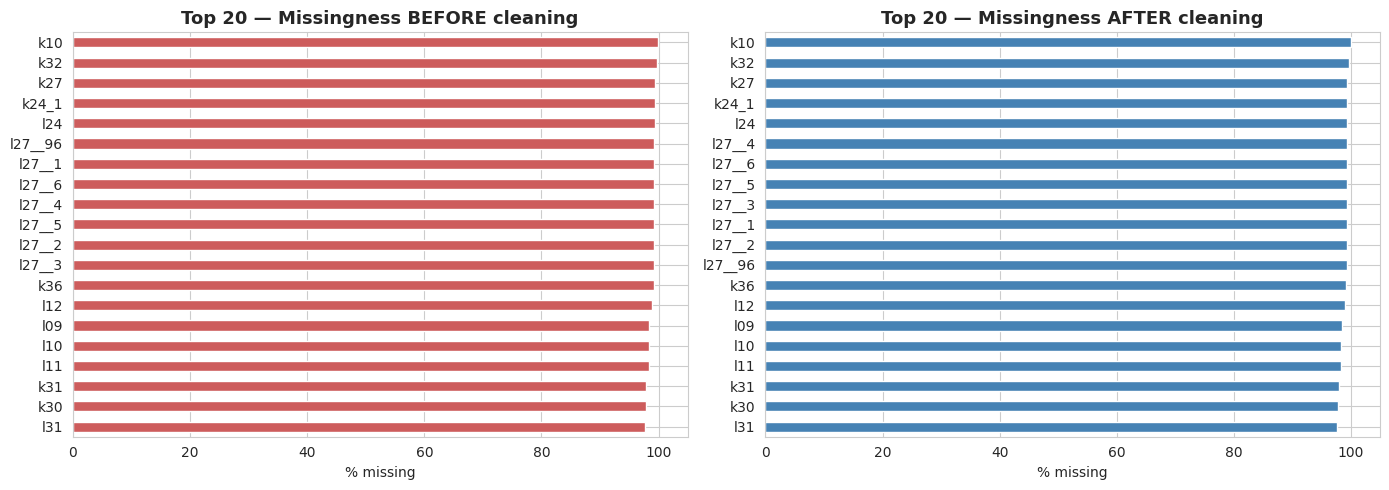

In [182]:
# ── 10.1  Missingness: before vs after ────────────────────────────────────
missing_after_all = (master.isnull().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_before.head(20)['pct_missing'].plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Top 20 — Missingness BEFORE cleaning')
axes[0].invert_yaxis()
axes[0].set_xlabel('% missing')

missing_after_all.sort_values(ascending=False).head(20).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 — Missingness AFTER cleaning')
axes[1].invert_yaxis()
axes[1].set_xlabel('% missing')

plt.tight_layout()
plt.savefig(FIGS / 'missingness_before_after.png', dpi=150)
plt.show()


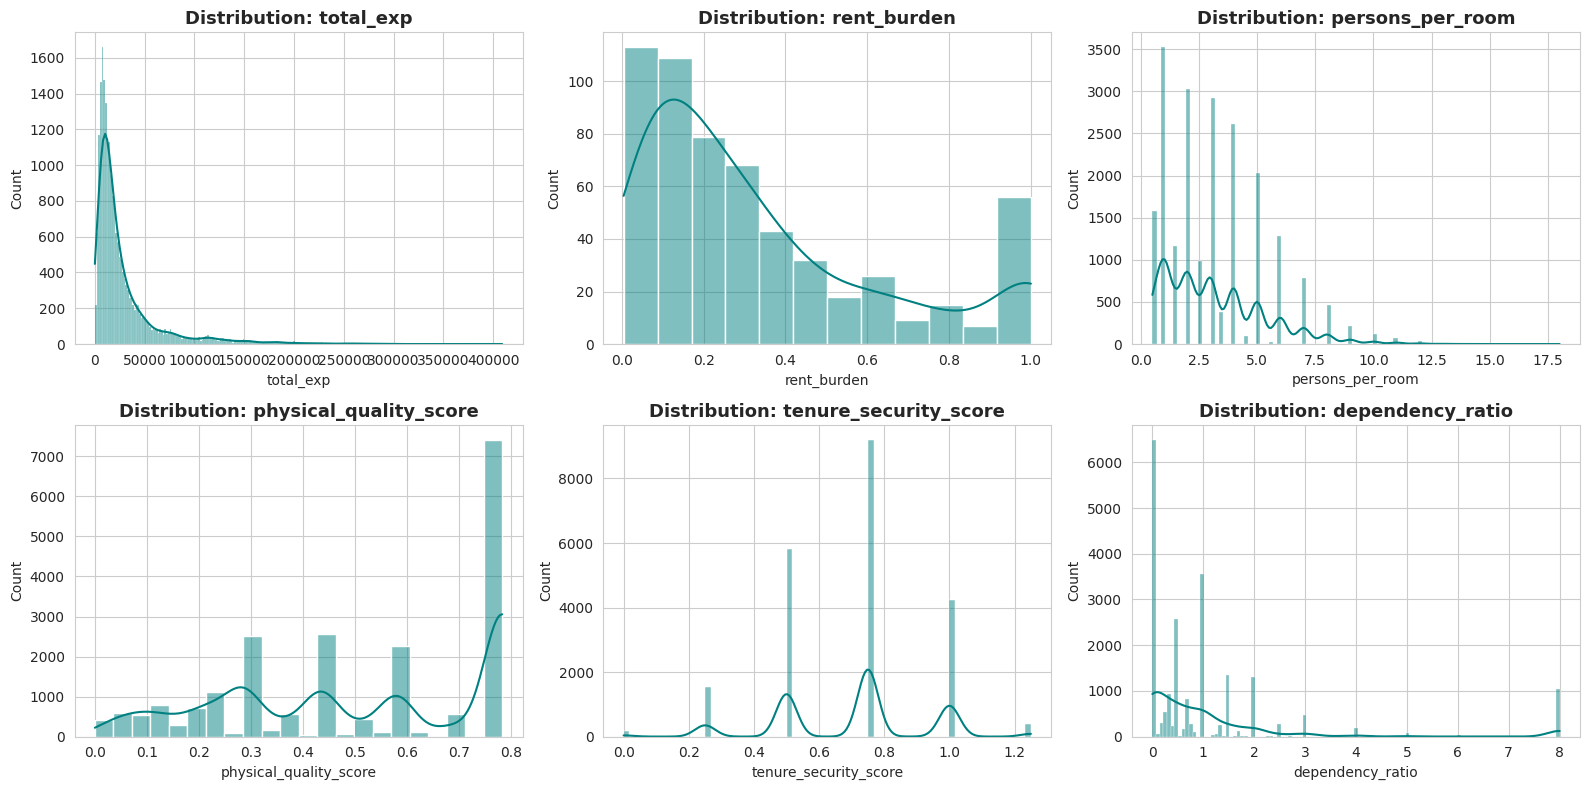

In [183]:
# ── 10.2  Distributions of engineered variables ──────────────────────────
plot_vars = ['total_exp', 'rent_burden', 'persons_per_room',
              'physical_quality_score', 'tenure_security_score', 'dependency_ratio']
plot_vars = [v for v in plot_vars if v in master.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, plot_vars):
    sns.histplot(master[col].dropna(), kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig(FIGS / 'engineered_distributions.png', dpi=150)
plt.show()


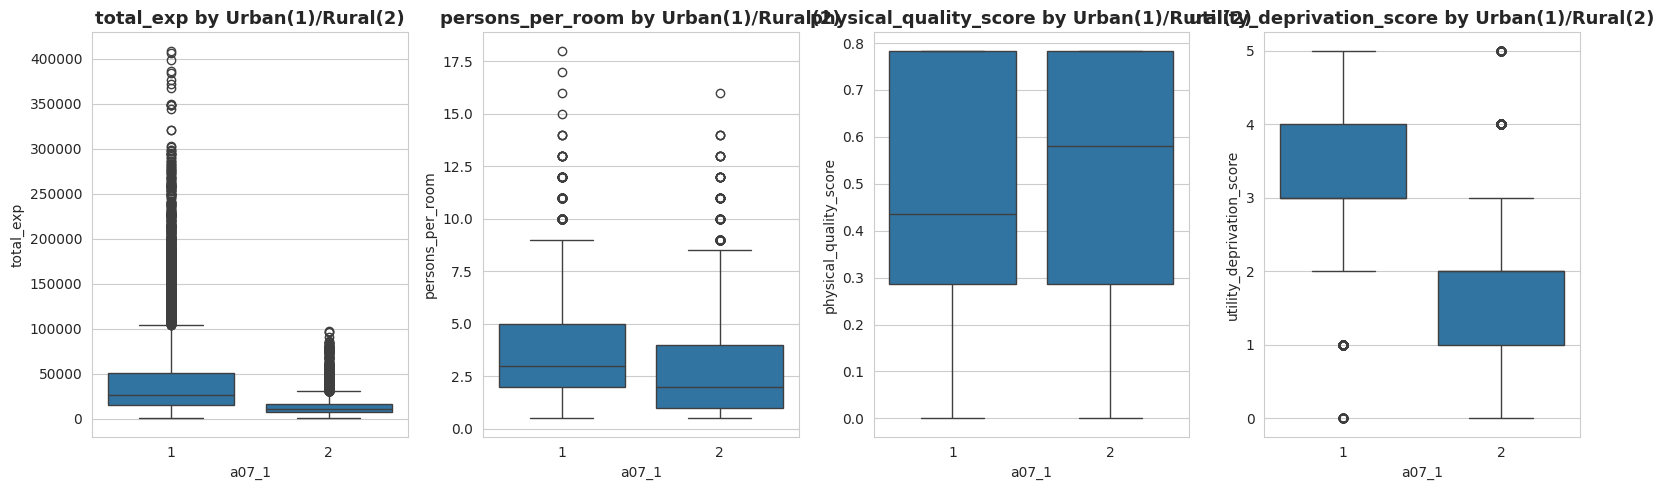

In [184]:
# ── 10.3  Urban vs Rural splits ───────────────────────────────────────────
split_vars = ['total_exp', 'persons_per_room', 'physical_quality_score', 'utility_deprivation_score']
split_vars = [v for v in split_vars if v in master.columns]

fig, axes = plt.subplots(1, len(split_vars), figsize=(4*len(split_vars), 5))
for ax, col in zip(np.atleast_1d(axes), split_vars):
    sns.boxplot(x='a07_1', y=col, data=master, ax=ax)
    ax.set_title(f'{col} by Urban(1)/Rural(2)')
    ax.set_xlabel('a07_1')
plt.tight_layout()
plt.savefig(FIGS / 'urban_rural_splits.png', dpi=150)
plt.show()


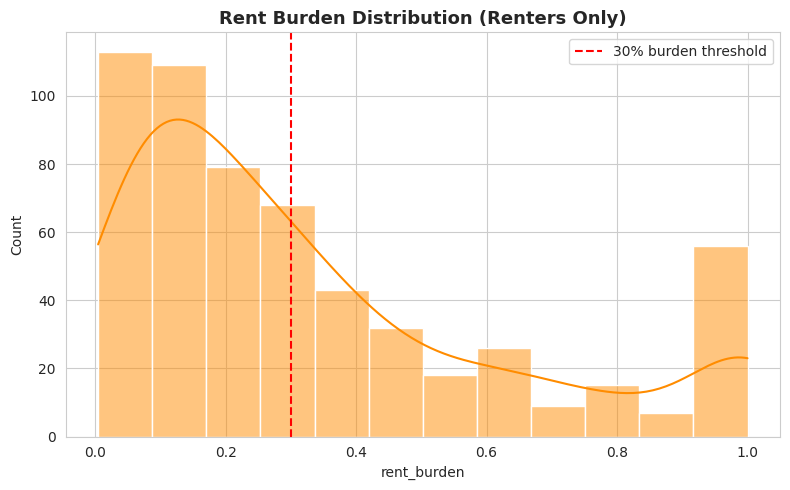

In [185]:
# ── 10.4  Renters only: rent burden ────────────────────────────────────────
if 'rent_burden' in master.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(master.loc[master['is_renter'] == 1, 'rent_burden'].dropna(),
                  kde=True, ax=ax, color='darkorange')
    ax.axvline(0.30, color='red', linestyle='--', label='30% burden threshold')
    ax.set_title('Rent Burden Distribution (Renters Only)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGS / 'rent_burden_distribution.png', dpi=150)
    plt.show()


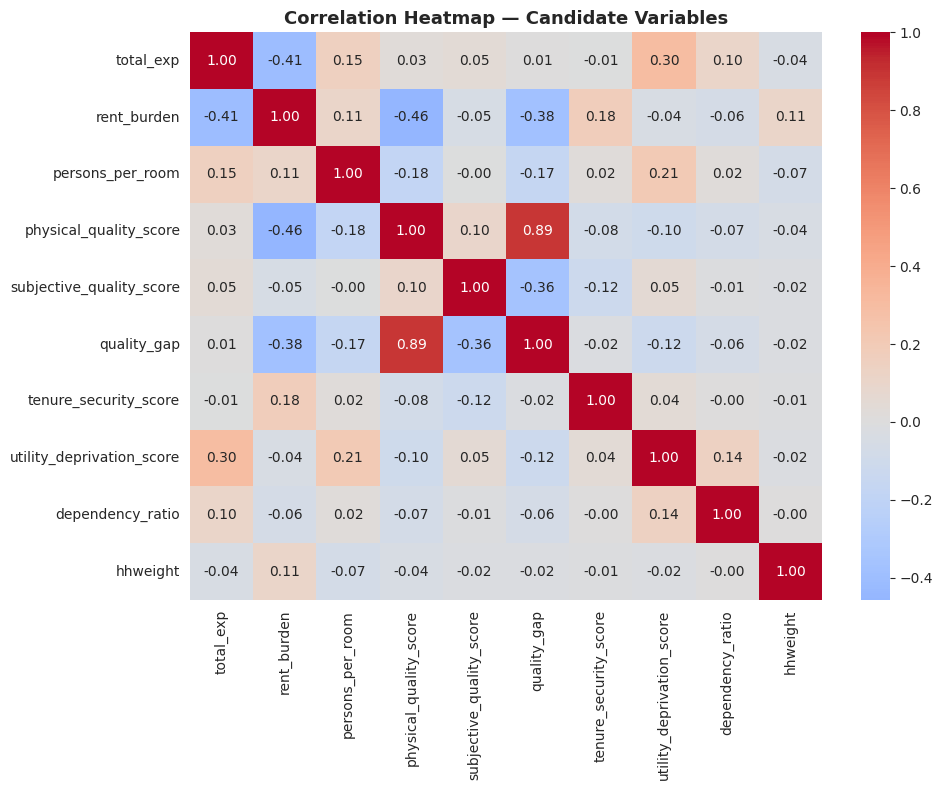

In [186]:
# ── 10.5  Correlation heatmap — candidate continuous variables ───────────
corr_candidates = ['total_exp', 'rent_burden', 'persons_per_room', 'physical_quality_score',
                    'subjective_quality_score', 'quality_gap', 'tenure_security_score',
                    'utility_deprivation_score', 'dependency_ratio', 'hhweight']
corr_candidates = [v for v in corr_candidates if v in master.columns]

corr = master[corr_candidates].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Candidate Variables')
plt.tight_layout()
plt.savefig(FIGS / 'correlation_heatmap_candidates.png', dpi=150)
plt.show()


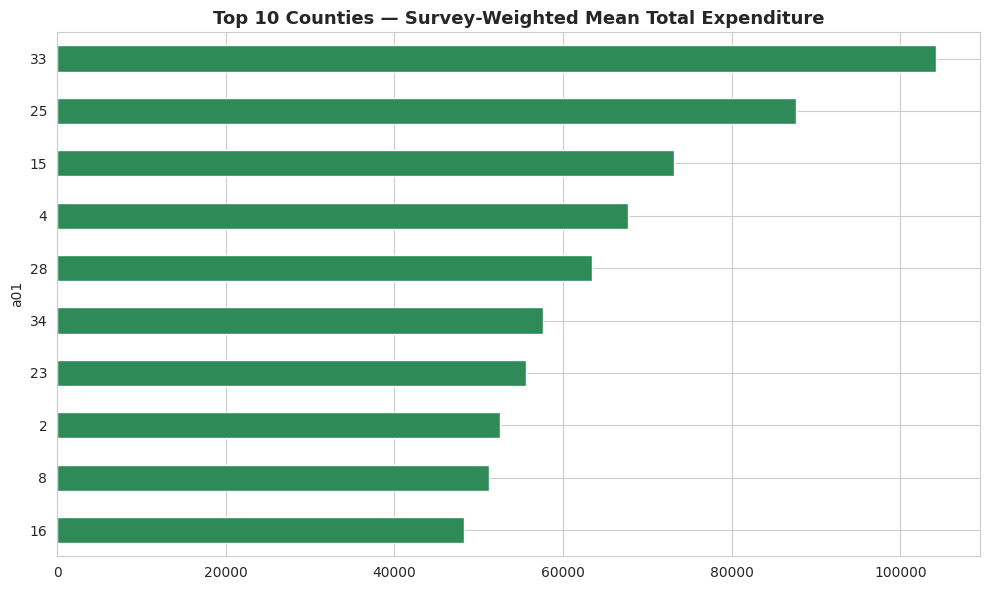

In [187]:
# ── 10.6  County-level view (survey-weighted) ─────────────────────────────
# Section 7 of Data_Understanding.md: all county aggregates must use hhweight.
def weighted_mean(df, col, weight_col='hhweight'):
    return np.average(df[col], weights=df[weight_col])

if {'hhweight', 'total_exp'}.issubset(master.columns):
    county_summary = (
        master.groupby('a01')
        .apply(lambda g: pd.Series({
            'weighted_total_exp': weighted_mean(g, 'total_exp'),
            'n_households': len(g)
        }))
        .sort_values('weighted_total_exp', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    county_summary['weighted_total_exp'].head(10).plot(kind='barh', ax=ax, color='seagreen')
    ax.set_title('Top 10 Counties — Survey-Weighted Mean Total Expenditure')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGS / 'county_weighted_total_exp_top10.png', dpi=150)
    plt.show()


---
## 11. Candidate Analytical Stories — Decision Point

Based on what survived cleaning and what the visuals in Section 10 show, here are **candidate
analytical stories** for the DSA8301 report. Each gives a research question, the variables
involved (with type, per the registry), and the *likely* test family — to be confirmed by the
Shapiro-Wilk normality test in the next notebook (Phase 3).

> Fill in the "Observed pattern" column after reviewing Section 10's plots, then pick **one**
> primary story (plus 1–2 supporting analyses) to carry through Phases 3–5.

| # | Research question | Key variables | Types | Likely test family | Observed pattern (fill in) |
|---|---|---|---|---|---|
| A | Does **rent burden** differ between urban and rural renters? | `rent_burden` (cont.), `a07_1` (binary group) | continuous vs. binary group | 2-sample t-test / Mann-Whitney U | |
| B | Does **total expenditure** vary across counties / regions? | `total_exp` (cont.), `a01` (group, 3+ levels) | continuous vs. categorical (3+) | ANOVA / Kruskal-Wallis | |
| C | Is there a relationship between **physical quality** and **utility deprivation**? | `physical_quality_score`, `utility_deprivation_score` (both cont.) | continuous vs. continuous | Pearson / Spearman correlation, regression | |
| D | Does **tenure security** predict **rent burden** (controlling for urban/rural)? | `tenure_security_score`, `rent_burden`, `a07_1` | continuous outcome, continuous + categorical predictors | Multiple linear regression | |
| E | Is the **objective–subjective quality gap** evenly distributed, or concentrated in specific groups (e.g., rural, low-tenure-security)? | `quality_gap` (cont.), `a07_1` / `tenure_security_score` | continuous vs. group | t-test/ANOVA or correlation, depending on grouping | |
| F | Are **dependency ratio** and **persons per room** associated (crowding ↔ household composition)? | `dependency_ratio`, `persons_per_room` (both cont.) | continuous vs. continuous | Pearson / Spearman correlation | |

**Note on `hhweight`:** per Section 7 of `Data_Understanding.md`, this is an analytical weight, not
a feature — it must not enter any of the above as a predictor or grouping variable, but should be
used if any story is extended to produce population-representative county-level estimates.


---
## 12. Save Cleaned Data for the Next Notebook

Two outputs:
1. **Full cleaned master frame** — all 443(+engineered) columns, for reference / future pillar work.
2. **DSA8301 working subset** — the columns needed for the chosen story (Section 11) plus the full
   engineered-feature set and key demographics, small enough to move into Phase 3 (normality
   testing) cleanly.


In [188]:
# ── 12.0  Final cleaned dataset — data type inventory ────────────────────
# Run this cell BEFORE saving to confirm the working subset is correctly typed.

type_map = []
for col in WORKING_SUBSET_COLS:
    if col not in master.columns:
        continue

    reg_entry = VARIABLE_REGISTRY.get(col, {})
    reg_type  = reg_entry.get('type', 'unregistered')
    label     = reg_entry.get('label', '—')
    pandas_dtype = str(master[col].dtype)
    n_null    = master[col].isnull().sum()
    n_unique  = master[col].nunique(dropna=True)

    type_map.append({
        'column'        : col,
        'label'         : label,
        'registry_type' : reg_type,
        'pandas_dtype'  : pandas_dtype,
        'n_null'        : n_null,
        'pct_null'      : round(n_null / len(master) * 100, 1),
        'n_unique'      : n_unique,
    })

type_df = pd.DataFrame(type_map).sort_values('registry_type')
print(f"\nWorking subset: {len(type_df)} columns\n")
print(type_df.groupby('registry_type')['column'].count().rename('n_cols').to_string())
print()
type_df


Working subset: 19 columns

registry_type
binary           4
categorical      1
continuous       1
id               1
unregistered    12



,column,label,registry_type,pandas_dtype,n_null,pct_null,n_unique
18,i00,"Household owns land (0=No, 1=Yes)",binary,float64,1,0.0000,2
2,a07_1,"Urban/Rural stratum (1=Urban, 2=Rural)",binary,int8,0,0.0000,2
16,g02,"Household pays rent (1=Yes, 2=No)",binary,float64,0,0.0000,2
17,j04_1,"Current tenure arrangement (1=owner, 0=other)",binary,float64,0,0.0000,3
1,a01,County code (1–47),categorical,Int64,0,0.0000,47
3,hhweight,Household survey weight,continuous,float64,0,0.0000,1270
0,interview__key,Household unique interview key,id,object,0,0.0000,21347
7,is_renter,—,unregistered,int64,0,0.0000,2
8,persons_per_room,—,unregistered,float64,1,0.0000,27
5,rent_burden,—,unregistered,float64,20772,97.3000,479


In [189]:
# ── Fix lp_n_parcels: replace 'No land' sentinel with 0, cast to float
master['lp_n_parcels'] = pd.to_numeric(master['lp_n_parcels'].replace('No land', 0), errors='coerce')

print(master['lp_n_parcels'].dtype)
print(master['lp_n_parcels'].value_counts().head())

float64
lp_n_parcels
0.0000    11640
1.0000     8517
2.0000     1004
3.0000      147
4.0000       30
Name: count, dtype: int64


In [190]:
# ── 12.1  Save full cleaned frame ─────────────────────────────────────────
CLEANED_PATH = PQ / 'master_frame_clean.parquet'
master.to_parquet(CLEANED_PATH)
print(f"Saved full cleaned frame: {master.shape} -> {CLEANED_PATH}")


Saved full cleaned frame: (21347, 527) -> /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_frame_clean.parquet


In [191]:
# ── 12.2  Build & save the DSA8301 working subset ────────────────────────
# Adjust this list once the story is chosen in Section 11.
WORKING_SUBSET_COLS = [
    'interview__key', 'a01', 'a07_1', 'hhweight',
    'total_exp', 'rent_burden', 'rent_burdened', 'is_renter',
    'persons_per_room', 'physical_quality_score', 'subjective_quality_score',
    'quality_gap', 'tenure_security_score', 'triple_exposed',
    'utility_deprivation_score', 'dependency_ratio',
    'g02', 'j04_1', 'i00',
]
WORKING_SUBSET_COLS = [c for c in WORKING_SUBSET_COLS if c in master.columns]

dsa_df = master[WORKING_SUBSET_COLS].copy()
WORKING_PATH = PQ / 'dsa8301_working_subset.parquet'
dsa_df.to_parquet(WORKING_PATH)

print(f"Working subset: {dsa_df.shape} -> {WORKING_PATH}")
dsa_df.head()


Working subset: (21347, 19) -> /content/drive/MyDrive/KHS_Dissertation/data/parquet/dsa8301_working_subset.parquet


,interview__key,a01,a07_1,hhweight,total_exp,rent_burden,rent_burdened,is_renter,persons_per_room,physical_quality_score,subjective_quality_score,quality_gap,tenure_security_score,triple_exposed,utility_deprivation_score,dependency_ratio,g02,j04_1,i00
0,00-00-55-14,31,2,182.4144,8110.0000,NaN,<NA>,0,6.0000,0.0418,0.3182,-0.2763,0.7500,0,3,1.0000,2.0000,1.0000,1.0000
1,00-01-22-52,14,2,199.0565,6750.0000,NaN,<NA>,0,3.0000,0.4352,0.3636,0.0715,0.5000,0,2,0.5000,2.0000,1.0000,1.0000
2,00-02-11-67,38,2,142.0923,7150.0000,NaN,<NA>,1,7.0000,0.2866,0.4091,-0.1225,1.2500,0,3,0.7500,1.0000,2.0000,0.0000
3,00-02-70-91,7,1,337.1762,50000.0000,NaN,<NA>,1,6.0000,0.7837,0.0909,0.6928,0.5000,0,3,0.5000,1.0000,1.0000,1.0000
4,00-02-78-46,14,2,183.4637,11500.0000,NaN,<NA>,0,4.0000,0.3645,0.5909,-0.2264,0.7500,0,2,0.3333,2.0000,2.0000,0.0000


---
## 13. Cleaning Summary Table (for the Report)

The workflow guide requires a **Preprocessing Summary Table**: issue found → treatment applied →
rows/values affected. Assemble it here from the logs collected throughout this notebook
(`CORRECTIONS_LOG`, `imputation_log_df`, `outlier_treatment_df`, `consistency_df`, and the Section
4/5 structural-encoding and provenance decisions).


In [192]:
# ── 13.0  Columns NOT in working subset — explicit justification ──────────
all_master_cols = set(master.columns)
working_cols    = set(WORKING_SUBSET_COLS)
dropped_cols    = all_master_cols - working_cols

drop_justification = {
    'id / admin'         : ['interview__key', 'serial', 'countycode'],
    'redundant with derived' : ['g01a','g01b','g01c','g01d','g01e','g01f',
                                 'g01g','g01h','g01i','g01j','g01k',
                                 'c14_1','c14_2','c14_3'],
    'structural / non-renters only' : ['k05', 'k02', 'k09', 'k21'],
    'provenance unverified'          : UNVERIFIED_EXCLUDE,
    'high missingness, not imputed'  : list(tier_df[tier_df['tier']=='High'].index),
    'county-level only (not HH-level)': [c for c in master.columns
                                           if c.startswith(('mort_','fin_','loan_'))
                                           and not c.endswith('_market_absent')],
    'pillar ingredient not needed for DSA8301 story' : [],  # fill in with d08/d09/d10 etc.
}

drop_rows = []
for reason, cols in drop_justification.items():
    for col in cols:
        if col in dropped_cols:
            drop_rows.append({'column': col, 'reason_dropped': reason})

drop_df = pd.DataFrame(drop_rows).sort_values('reason_dropped')
print(f"Columns in master but NOT in working subset: {len(dropped_cols)}")
print(f"Justified above: {len(drop_df)}")
drop_df

Columns in master but NOT in working subset: 508
Justified above: 196


,column,reason_dropped
195,fin_n_financiers,county-level only (not HH-level)
186,mort_interest_rate,county-level only (not HH-level)
187,mort_ltv_ratio,county-level only (not HH-level)
188,mort_avg_term_years,county-level only (not HH-level)
189,mort_n_providers,county-level only (not HH-level)
...,...,...
2,g01a,redundant with derived
19,k21,structural / non-renters only
16,k05,structural / non-renters only
17,k02,structural / non-renters only


In [193]:
# ── 13.1  Assemble final summary table ────────────────────────────────────
summary_rows = []

# Sentinel corrections (Section 2)
for var, action, n in CORRECTIONS_LOG:
    summary_rows.append({'Issue': f'Sentinel/invalid value in {var}', 'Treatment': action, 'Rows/Values Affected': n})

# Structural missingness (Section 4)
summary_rows.append({'Issue': 'lp_* columns null for non-landowners (i00==0)',
                      'Treatment': "Encoded as 0 / 'No land' (structural, not imputed)",
                      'Rows/Values Affected': int(master['i00'].eq(0).sum()) if 'i00' in master.columns else 'n/a'})
summary_rows.append({'Issue': 'k05 null for non-renters',
                      'Treatment': "Left as NaN (structural); is_renter flag created",
                      'Rows/Values Affected': int((master['is_renter'] == 0).sum())})
summary_rows.append({'Issue': 'mort_/fin_/loan_ county aggregates null (60-81%)',
                      'Treatment': "*_market_absent flag created; value filled with 0",
                      'Rows/Values Affected': f'{len(mort_fin_cols)} columns'})

# Provenance (Section 5)
summary_rows.append({'Issue': 'prop_util / med_prop / med_brms / min_rent — unverified provenance',
                      'Treatment': f"Excluded: {UNVERIFIED_EXCLUDE}" if UNVERIFIED_EXCLUDE else "Retained — verification passed (see Section 5)",
                      'Rows/Values Affected': '4 columns'})

# Imputation (Section 6)
for _, row in imputation_log_df.iterrows():
    summary_rows.append({'Issue': f"{row['variable']} — {row['pct_missing_before']}% missing ({row['tier']})",
                          'Treatment': row['method'],
                          'Rows/Values Affected': f"{row['pct_missing_before']}% of rows"})

# Outliers (Section 7)
for _, row in outlier_treatment_df.iterrows():
    summary_rows.append({'Issue': f"{row['variable']} — extreme values",
                          'Treatment': 'Winsorized at [1st, 99th] percentile, by a07_1',
                          'Rows/Values Affected': f"{row['pct_capped']}% capped"})

# Consistency (Section 8)
for _, row in consistency_df.iterrows():
    if row['n_rows_flagged'] > 0:
        summary_rows.append({'Issue': row['check'],
                              'Treatment': 'Reviewed — see Section 8 resolution notes',
                              'Rows/Values Affected': int(row['n_rows_flagged'])})

cleaning_summary = pd.DataFrame(summary_rows)
cleaning_summary.to_csv(TABS / 'preprocessing_summary.csv', index=False)
print(f"Cleaning summary: {len(cleaning_summary)} rows -> {TABS / 'preprocessing_summary.csv'}")
cleaning_summary


Cleaning summary: 199 rows -> /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/preprocessing_summary.csv


,Issue,Treatment,Rows/Values Affected
0,lp_* columns null for non-landowners (i00==0),"Encoded as 0 / 'No land' (structural, not impu...",11639
1,k05 null for non-renters,Left as NaN (structural); is_renter flag created,16674
2,mort_/fin_/loan_ county aggregates null (60-81%),*_market_absent flag created; value filled with 0,10 columns
3,prop_util / med_prop / med_brms / min_rent — u...,Retained — verification passed (see Section 5),4 columns
4,c01_4 — 47.07% missing (Moderate),group median (a07_1),47.07% of rows
...,...,...,...
194,l14 — extreme values,"Winsorized at [1st, 99th] percentile, by a07_1",1.42% capped
195,c14_1 — extreme values,"Winsorized at [1st, 99th] percentile, by a07_1",0.9% capped
196,c14_2 — extreme values,"Winsorized at [1st, 99th] percentile, by a07_1",0.72% capped
197,c14_3 — extreme values,"Winsorized at [1st, 99th] percentile, by a07_1",0.85% capped


---
## Next Notebook

With `master_frame_clean.parquet` and `dsa8301_working_subset.parquet` saved, the next notebook
implements the rest of **Phase 3** (descriptive statistics table, Q-Q plots, Shapiro-Wilk normality
table — the **critical decision gate**) for the variables shortlisted in Section 11, followed by
Phases 4 and 5 (parametric and nonparametric test batteries) on whichever story was chosen.
